# EDA

In [ ]:
accounts = pd.read_csv('ravenstack_accounts.csv')
churn = pd.read_csv('ravenstack_churn_events.csv')
feature = pd.read_csv('ravenstack_feature_usage.csv')
subs = pd.read_csv('ravenstack_subscriptions.csv')
tickets = pd.read_csv('ravenstack_support_tickets.csv')

## Cek Missing Values

In [ ]:
kumpulan_df = {
    'Accounts': accounts,
    'Churn Events': churn,
    'Feature Usage': feature,
    'Subscriptions': subs,
    'Support Tickets': tickets
}


for nama, df in kumpulan_df.items():
    print(f"--- Cek Missing Values: {nama} ---")
    
    # Langsung hitung dan jadikan tabel dalam satu langkah
    print(pd.DataFrame({
        'Jumlah Kosong': df.isna().sum(),
        'Persentase (%)': (df.isna().mean() * 100).round(2)
    }))
    
    print("-" * 40, "\n")

--- Cek Missing Values: Accounts ---
                 Jumlah Kosong  Persentase (%)
account_id                   0             0.0
account_name                 0             0.0
industry                     0             0.0
country                      0             0.0
signup_date                  0             0.0
referral_source              0             0.0
plan_tier                    0             0.0
seats                        0             0.0
is_trial                     0             0.0
churn_flag                   0             0.0
---------------------------------------- 

--- Cek Missing Values: Churn Events ---
                          Jumlah Kosong  Persentase (%)
churn_event_id                        0            0.00
account_id                            0            0.00
churn_date                            0            0.00
reason_code                           0            0.00
refund_amount_usd                     0            0.00
preceding_upgrade_flag    

Nilai null ditemukan pada df Churn Events, Subscriptions dan Support Tickets

-Pada Churn Events, terdapat kolom feedback_text dengan jumlah null 148 atau 24,67 dari kolom tersebut bernilai null, yang berarti pelanggan tidak memberikan feedback atau alasan kenapa berhenti berlangganan.

-Pada Support Tickets, terdapat 825 nilai kosong pada kolom satisfaction_score (41,25%), yang  disebabkan oleh user yang tidak mengisi survei kepuasan setelah masalah selesai.

-Pada Subscriptions, kolom end_date memiliki nilai kosong sebanyak 4514 atau sekitar 90.28 % dari keseluruhan nilai di kolom end_date. Hal ini berarti pengguna belum berhenti berlangganan, karena end_date tidak ada

## Info tiap df

In [ ]:
for nama, df in kumpulan_df.items():
    print(f"========== INFO DATASET: {nama} ==========")
    df.info() 
    print("\n\n")

========== INFO DATASET: Accounts ==========
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   account_id       500 non-null    str  
 1   account_name     500 non-null    str  
 2   industry         500 non-null    str  
 3   country          500 non-null    str  
 4   signup_date      500 non-null    str  
 5   referral_source  500 non-null    str  
 6   plan_tier        500 non-null    str  
 7   seats            500 non-null    int64
 8   is_trial         500 non-null    bool 
 9   churn_flag       500 non-null    bool 
dtypes: bool(2), int64(1), str(7)
memory usage: 32.4 KB



========== INFO DATASET: Churn Events ==========
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id   

## Cek Duplikat

In [ ]:
for nama, df in kumpulan_df.items():
    print(f"--- Cek Data Duplikat: {nama} ---")
    
    # Menghitung jumlah baris yang duplikat
    jumlah_duplikat = df.duplicated().sum()
    print(f"Jumlah baris duplikat: {jumlah_duplikat}")
    
    print( "\n")

--- Cek Data Duplikat: Accounts ---
Jumlah baris duplikat: 0


--- Cek Data Duplikat: Churn Events ---
Jumlah baris duplikat: 0


--- Cek Data Duplikat: Feature Usage ---
Jumlah baris duplikat: 0


--- Cek Data Duplikat: Subscriptions ---
Jumlah baris duplikat: 0


--- Cek Data Duplikat: Support Tickets ---
Jumlah baris duplikat: 0




## Cek Foreign Key dan Relasi antar tabel df

In [ ]:
cek_subs = subs['account_id'].isin(accounts['account_id']).all()
cek_tickets = tickets['account_id'].isin(accounts['account_id']).all()
cek_churn = churn['account_id'].isin(accounts['account_id']).all()
cek_feature = feature['subscription_id'].isin(subs['subscription_id']).all()

In [ ]:
print('Semua account_id dari tabel Subscriptions ada di tabel Accounts :', cek_subs)
print('Semua account_id dari tabel Tickets ada di tabel Accounts       :', cek_tickets)
print('Semua account_id dari tabel Churn ada di tabel Accounts         :', cek_churn)
print('Semua subscription_id dari tabel Feature ada di tabel Subs      :', cek_feature)

Semua account_id dari tabel Subscriptions ada di tabel Accounts : True
Semua account_id dari tabel Tickets ada di tabel Accounts       : True
Semua account_id dari tabel Churn ada di tabel Accounts         : True
Semua subscription_id dari tabel Feature ada di tabel Subs      : True


## Shape atau ukuran baris dan kolom tiap df

In [ ]:
for nama, df in kumpulan_df.items() :
    print('nama df :', nama)
    print('ukuran (baris/kolom) : ', df.shape)
    print()

nama df : Accounts
ukuran (baris/kolom) :  (500, 10)

nama df : Churn Events
ukuran (baris/kolom) :  (600, 9)

nama df : Feature Usage
ukuran (baris/kolom) :  (25000, 8)

nama df : Subscriptions
ukuran (baris/kolom) :  (5000, 14)

nama df : Support Tickets
ukuran (baris/kolom) :  (2000, 9)



## Cek duplikat primary key tiap df

In [ ]:

print("\n=== CEK DUPLIKAT PADA ID UTAMA ===")
print("Duplikat account_id di Accounts                  :", accounts.duplicated(subset=['account_id']).sum())
print("Duplikat subscription_id di Subs                 :", subs.duplicated(subset=['subscription_id']).sum())
print("Duplikat ticket_id di Tickets                    :", tickets.duplicated(subset=['ticket_id']).sum())
print("Duplikat churn_event_id di churn_events          :", churn.duplicated(subset=['churn_event_id']).sum())
print("Duplikat usage_id di feature_usage               :", feature.duplicated(subset=['usage_id']).sum())



=== CEK DUPLIKAT PADA ID UTAMA ===
Duplikat account_id di Accounts                  : 0
Duplikat subscription_id di Subs                 : 0
Duplikat ticket_id di Tickets                    : 0
Duplikat churn_event_id di churn_events          : 0
Duplikat usage_id di feature_usage               : 21


In [ ]:
# keep=False akan menampilkan  data duplikat dan data aslinya
duplikat_usage = feature[feature.duplicated(subset=['usage_id'], keep=False)]

duplikat_usage.sort_values(by='usage_id').head(10)

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
19294,U-0c9318,S-01b2dc,2023-12-11,feature_9,5,1060,3,False
17533,U-0c9318,S-0ffab0,2024-01-30,feature_11,3,1614,0,False
20588,U-13ce5b,S-9b623b,2023-03-26,feature_28,10,2050,1,False
9626,U-13ce5b,S-8b0950,2024-09-10,feature_9,8,824,0,True
18480,U-2103bb,S-7fc49b,2023-04-18,feature_12,9,5022,1,False
10379,U-2103bb,S-ae3270,2024-01-06,feature_3,10,5510,0,False
22,U-25b56c,S-810c27,2024-10-06,feature_20,7,231,0,False
7574,U-25b56c,S-34253c,2023-10-28,feature_20,6,2166,1,False
21376,U-48a4aa,S-93f835,2024-08-24,feature_39,10,4770,0,False
1085,U-48a4aa,S-383ac2,2023-02-12,feature_28,14,7126,0,False


ditemukan 21 duplikat usage_id pada df feature dari 25000 baris. usage_id tidak digunakan sebagai foreign key. Karena usage_id yang duplikat hanya sedikit dan tidak digunakan sebagai foreign key sehingga tidak akan dilakukan apa-apa pada data tersebut.

## cek lain-lain

In [ ]:
print("=== 1. CEK KESALAHAN WAKTU ===")
# Subscriptions: start_date lebih dari end_date
waktu_subs_error = subs[subs['start_date'] > subs['end_date']]
print(f"Subs (start > end)     : {len(waktu_subs_error)} baris")

# Support Tickets: ditutup sebelum dikirim
waktu_tickets_error = tickets[tickets['closed_at'] < tickets['submitted_at']]
print(f"Tickets (closed < sub) : {len(waktu_tickets_error)} baris")

=== 1. CEK KESALAHAN WAKTU ===
Subs (start > end)     : 0 baris
Tickets (closed < sub) : 0 baris


In [ ]:
print("\n=== 2. CEK ATURAN BISNIS & NILAI NEGATIF ===")
# Accounts: seats kurang dari 1
seats_error = accounts[accounts['seats'] < 1]
print(f"Accounts (seats < 1)         : {len(seats_error)} baris")

# Subscriptions: mrr atau arr negatif
uang_negatif = subs[(subs['mrr_amount'] < 0) | (subs['arr_amount'] < 0)]
print(f"Subs (MRR/ARR negatif)       : {len(uang_negatif)} baris")

# Subscriptions: end_date kosong tapi ada di tabel churn
akun_yg_churn = churn['account_id'].unique()
subs_churn_anomali = subs[(subs['end_date'].isnull()) & (subs['account_id'].isin(akun_yg_churn))]
print(f"Subs (Churn tapi end_date kosong): {len(subs_churn_anomali)} baris")

# Feature Usage: usage_count atau duration negatif
usage_negatif = feature[(feature['usage_count'] < 0) | (feature['usage_duration_secs'] < 0)]
print(f"Usage (Count/Duration < 0)   : {len(usage_negatif)} baris")




=== 2. CEK ATURAN BISNIS & NILAI NEGATIF ===
Accounts (seats < 1)         : 0 baris
Subs (MRR/ARR negatif)       : 0 baris
Subs (Churn tapi end_date kosong): 3176 baris
Usage (Count/Duration < 0)   : 0 baris


In [ ]:
tiket_negatif = tickets[(tickets['resolution_time_hours'] < 0) | (tickets['first_response_time_minutes'] < 0)]
refund_negatif = churn[churn['refund_amount_usd'] < 0]

print(f"Tickets (Waktu respon < 0)  : {len(tiket_negatif)} baris")
print(f"Churn (Refund < 0)          : {len(refund_negatif)} baris")

Tickets (Waktu respon < 0)  : 0 baris
Churn (Refund < 0)          : 0 baris


In [ ]:
print("\n=== 3. CEK DATA ORPHAN (TIDAK ADA INDUK) ===")
# Feature Usage: subscription_id tidak ada di tabel Subs
orphan_usage = feature[~feature['subscription_id'].isin(subs['subscription_id'])]
print(f"Usage (Orphan Subs ID) : {len(orphan_usage)} baris")

# Churn Events: account_id tidak ada di tabel Accounts
orphan_churn = churn[~churn['account_id'].isin(accounts['account_id'])]
print(f"Churn (Orphan Akun)    : {len(orphan_churn)} baris")


=== 3. CEK DATA ORPHAN (TIDAK ADA INDUK) ===
Usage (Orphan Subs ID) : 0 baris
Churn (Orphan Akun)    : 0 baris


In [ ]:
print("\n=== 4. CEK INKONSISTENSI STATUS ===")
# Asumsi churn_flag berisi True/False atau 1/0
inkonsisten_flag = accounts[
    # Kasus 1: Flag mengatakan Churn, tapi tidak ada datanya di tabel Churn
    ((accounts['churn_flag'] == True) & (~accounts['account_id'].isin(akun_yg_churn))) |
    # Kasus 2: Flag mengatakan Aktif (False), tapi ternyata ada datanya di tabel Churn
    ((accounts['churn_flag'] == False) & (accounts['account_id'].isin(akun_yg_churn)))
]
print(f"Accounts (Churn Flag Error) : {len(inkonsisten_flag)} baris")


=== 4. CEK INKONSISTENSI STATUS ===
Accounts (Churn Flag Error) : 312 baris


## Distribusi nilai kategorikal kolom pada tiap tabel df

In [ ]:
for nama_tabel, df in kumpulan_df.items():
    print(f"\n=============================================")
    print(f"  DISTRIBUSI KATEGORIKAL TABEL {nama_tabel.upper()}")
    print(f"=============================================")
    
    # Counter untuk mengecek apakah ada kolom kategorikal di tabel ini
    ada_kategori = False 
    
    for col in df.columns:
        # Hanya cetak jika jumlah nilai uniknya kurang dari 20
        if df[col].nunique() < 20:
            print(f"\n--- Kolom: {col} ---")
            print(df[col].value_counts(dropna=False))
            ada_kategori = True
            
    # Jika tabel tidak punya kolom dengan nilai unik < 20
    if not ada_kategori:
        print("\nTidak ada kolom kategorikal (< 20 nilai unik) di tabel ini.")


  DISTRIBUSI KATEGORIKAL TABEL ACCOUNTS

--- Kolom: industry ---
industry
DevTools         113
FinTech          112
Cybersecurity    100
HealthTech        96
EdTech            79
Name: count, dtype: int64

--- Kolom: country ---
country
US    291
UK     58
IN     49
AU     32
DE     25
CA     23
FR     22
Name: count, dtype: int64

--- Kolom: referral_source ---
referral_source
organic    114
other      103
ads         98
event       96
partner     89
Name: count, dtype: int64

--- Kolom: plan_tier ---
plan_tier
Pro           178
Basic         168
Enterprise    154
Name: count, dtype: int64

--- Kolom: is_trial ---
is_trial
False    403
True      97
Name: count, dtype: int64

--- Kolom: churn_flag ---
churn_flag
False    390
True     110
Name: count, dtype: int64

  DISTRIBUSI KATEGORIKAL TABEL CHURN EVENTS

--- Kolom: reason_code ---
reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64

--- K

## describe

In [ ]:
print("=== ACCOUNTS ===")
print(accounts.describe())

print("\n=== SUBSCRIPTIONS (kolom numerik terpilih) ===")
print(subs[['seats', 'mrr_amount', 'arr_amount']].describe())

print("\n=== FEATURE USAGE ===")
print(feature[['usage_count', 'usage_duration_secs', 'error_count']].describe())

print("\n=== SUPPORT TICKETS ===")
print(tickets[['resolution_time_hours', 'first_response_time_minutes', 'satisfaction_score']].describe())

# cek lebih detail distribusi satisfaction_score - ketauan ada anomali (nggak ada rating 1-2)
print("\n=== Distribusi satisfaction_score ===")
print(tickets['satisfaction_score'].value_counts().sort_index())

=== ACCOUNTS ===
            seats
count  500.000000
mean    20.560000
std     21.044718
min      1.000000
25%      5.000000
50%     15.000000
75%     28.000000
max    163.000000

=== SUBSCRIPTIONS (kolom numerik terpilih) ===
             seats    mrr_amount     arr_amount
count  5000.000000   5000.000000    5000.000000
mean     29.852000   2267.749400   27212.992800
std      23.089771   3421.375348   41056.504178
min       1.000000      0.000000       0.000000
25%      14.000000    285.000000    3420.000000
50%      24.000000    931.000000   11172.000000
75%      40.000000   2786.000000   33432.000000
max     189.000000  33830.000000  405960.000000

=== FEATURE USAGE ===
        usage_count  usage_duration_secs   error_count
count  25000.000000         25000.000000  25000.000000
mean      10.021000          3042.202880      0.564280
std        3.143729          2056.544615      1.012595
min        0.000000             0.000000      0.000000
25%        8.000000          1350.000000   

# eksplor

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('ravenstack.db')

## cohort based on singup

In [15]:
query_cohort1 = """
WITH RECURSIVE months(n) AS (
    SELECT 0
    UNION ALL
    SELECT n + 1 FROM months WHERE n < 12
),

cohort AS (
    SELECT account_id, strftime('%Y-%m-01', signup_date) AS cohort_month
    FROM accounts
),
cohort_size AS (
    SELECT cohort_month, COUNT(*) AS total_accounts
    FROM cohort
    GROUP BY cohort_month
),

first_churn AS (
    SELECT account_id, MIN(churn_date) AS churn_date
    FROM churn_events
    GROUP BY account_id
),

account_churn_index AS (
    SELECT
        c.account_id,
        c.cohort_month,
        CASE WHEN fc.churn_date IS NOT NULL THEN
            (CAST(strftime('%Y', fc.churn_date) AS INTEGER) - CAST(strftime('%Y', c.cohort_month) AS INTEGER)) * 12
            + (CAST(strftime('%m', fc.churn_date) AS INTEGER) - CAST(strftime('%m', c.cohort_month) AS INTEGER))
        END AS churn_month_index
    FROM cohort c
    LEFT JOIN first_churn fc ON fc.account_id = c.account_id
)

SELECT
    a.cohort_month,
    cs.total_accounts,
    m.n AS month_index,
    SUM(CASE WHEN a.churn_month_index IS NULL OR a.churn_month_index > m.n THEN 1 ELSE 0 END) AS active_accounts,
    ROUND(100.0 * SUM(CASE WHEN a.churn_month_index IS NULL OR a.churn_month_index > m.n THEN 1 ELSE 0 END) / cs.total_accounts, 2) AS retention_rate_pct
FROM account_churn_index a
JOIN cohort_size cs ON cs.cohort_month = a.cohort_month
CROSS JOIN months m
GROUP BY a.cohort_month, cs.total_accounts, m.n
ORDER BY a.cohort_month, m.n;
"""

df_cohort_singup = pd.read_sql(query_cohort1, conn)
df_cohort_singup.head(10)



,cohort_month,total_accounts,month_index,active_accounts,retention_rate_pct
0,2023-01-01,17,0,16,94.12
1,2023-01-01,17,1,16,94.12
2,2023-01-01,17,2,16,94.12
3,2023-01-01,17,3,15,88.24
4,2023-01-01,17,4,13,76.47
5,2023-01-01,17,5,13,76.47
6,2023-01-01,17,6,12,70.59
7,2023-01-01,17,7,12,70.59
8,2023-01-01,17,8,11,64.71
9,2023-01-01,17,9,10,58.82


In [16]:
df_cohort_singup.info()

<class 'pandas.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cohort_month        312 non-null    str    
 1   total_accounts      312 non-null    int64  
 2   month_index         312 non-null    int64  
 3   active_accounts     312 non-null    int64  
 4   retention_rate_pct  312 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 12.3 KB


In [17]:
pivot_signup = df_cohort_singup.pivot(
    index = 'cohort_month', 
    columns = 'month_index', 
    values = 'retention_rate_pct')

Text(0.5, 1.0, 'cohort retention based on signup date')

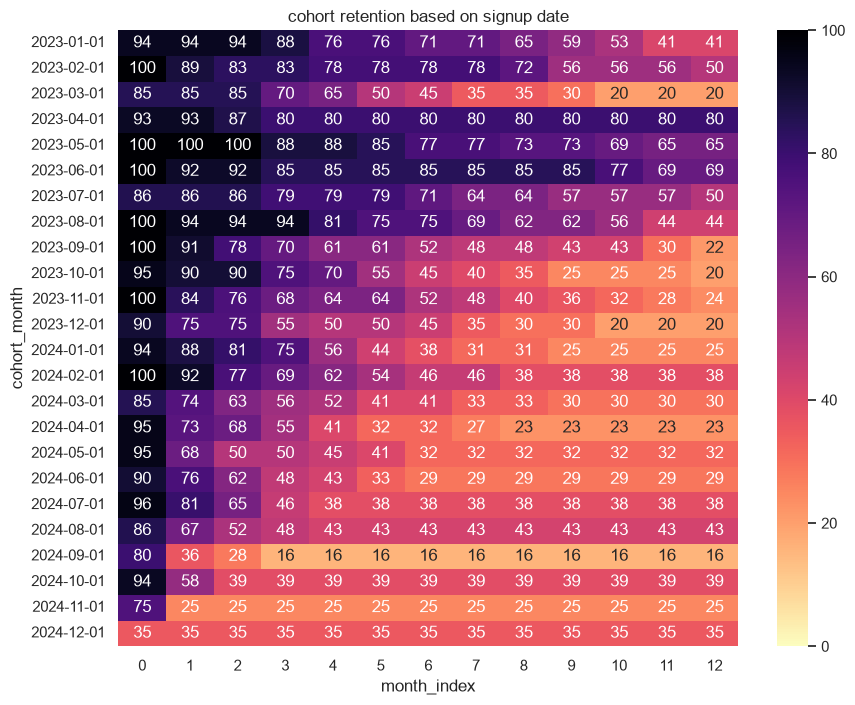

In [49]:
plt.figure(figsize=(10,8))
sns.heatmap(data = pivot_signup, vmin = 0, vmax = 100, cmap = 'magma_r', annot = True, fmt = '.0f')
plt.title('cohort retention based on signup date')

- Terjadi penurunan drastis retensi pengguna yang dimulai pada akhir tahun 2024 yaitu dari bulan September hingga Desember. Dengan puncak retensi yang paling buruk adalah bulan Desember 2024, dimana pada bulan ke-0 atau bulan dimana pengguna itu daftar hanya tersisa 35 % pengguna.
- Angkatan pengguna April 2023 merupakan angkatan terbaik karena memiliki retensi pengguna 80% bahkan setelah 12 bulan berlangganan.

## cohort based on subscription

In [52]:
query_cohort3 = """

WITH RECURSIVE months(n) AS (
    SELECT 0
    UNION ALL
    SELECT n + 1 FROM months WHERE n < 12
),

-- Langkah 1: cohort = bulan subscription PERTAMA tiap akun
cohort AS (
    SELECT account_id, strftime('%Y-%m-01', MIN(start_date)) AS cohort_month
    FROM subscriptions
    GROUP BY account_id
),
cohort_size AS (
    SELECT cohort_month, COUNT(*) AS total_accounts
    FROM cohort
    GROUP BY cohort_month
),

-- Langkah 2: cari tanggal churn PERTAMA tiap akun (kalau ada)
first_churn AS (
    SELECT account_id, MIN(churn_date) AS churn_date
    FROM churn_events
    GROUP BY account_id
),

-- Langkah 3: ubah tanggal churn jadi "bulan ke berapa" dari cohort_month
account_churn_index AS (
    SELECT
        c.account_id,
        c.cohort_month,
        CASE WHEN fc.churn_date IS NOT NULL THEN
            (CAST(strftime('%Y', fc.churn_date) AS INTEGER) - CAST(strftime('%Y', c.cohort_month) AS INTEGER)) * 12
            + (CAST(strftime('%m', fc.churn_date) AS INTEGER) - CAST(strftime('%m', c.cohort_month) AS INTEGER))
        END AS churn_month_index    -- NULL = nggak pernah churn
    FROM cohort c
    LEFT JOIN first_churn fc ON fc.account_id = c.account_id
)

-- Langkah 4: akun dianggap "masih aktif" di month_index tertentu
-- kalau belum pernah churn, ATAU churn-nya baru terjadi SETELAH month_index itu
SELECT
    a.cohort_month,
    cs.total_accounts,
    m.n AS month_index,
    SUM(CASE WHEN a.churn_month_index IS NULL OR a.churn_month_index > m.n THEN 1 ELSE 0 END) AS active_accounts,
    ROUND(100.0 * SUM(CASE WHEN a.churn_month_index IS NULL OR a.churn_month_index > m.n THEN 1 ELSE 0 END) / cs.total_accounts, 2) AS retention_rate_pct
FROM account_churn_index a
JOIN cohort_size cs ON cs.cohort_month = a.cohort_month
CROSS JOIN months m
GROUP BY a.cohort_month, cs.total_accounts, m.n
ORDER BY a.cohort_month, m.n;
    """

df_cohort_subscription = pd.read_sql(query_cohort3, conn)
df_cohort_subscription.head(10)

,cohort_month,total_accounts,month_index,active_accounts,retention_rate_pct
0,2023-01-01,2,0,2,100.0
1,2023-01-01,2,1,2,100.0
2,2023-01-01,2,2,2,100.0
3,2023-01-01,2,3,2,100.0
4,2023-01-01,2,4,2,100.0
5,2023-01-01,2,5,2,100.0
6,2023-01-01,2,6,2,100.0
7,2023-01-01,2,7,2,100.0
8,2023-01-01,2,8,2,100.0
9,2023-01-01,2,9,1,50.0


In [15]:
df_cohort_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cohort_month        312 non-null    str    
 1   total_accounts      312 non-null    int64  
 2   month_index         312 non-null    int64  
 3   active_accounts     312 non-null    int64  
 4   retention_rate_pct  312 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 12.3 KB


In [53]:
pivot_subscription = df_cohort_subscription.pivot(
    index = 'cohort_month', 
    columns = 'month_index', 
    values = 'retention_rate_pct')

<Axes: title={'center': 'heatmap retention cohort(subscription)'}, xlabel='month_index', ylabel='cohort_month'>

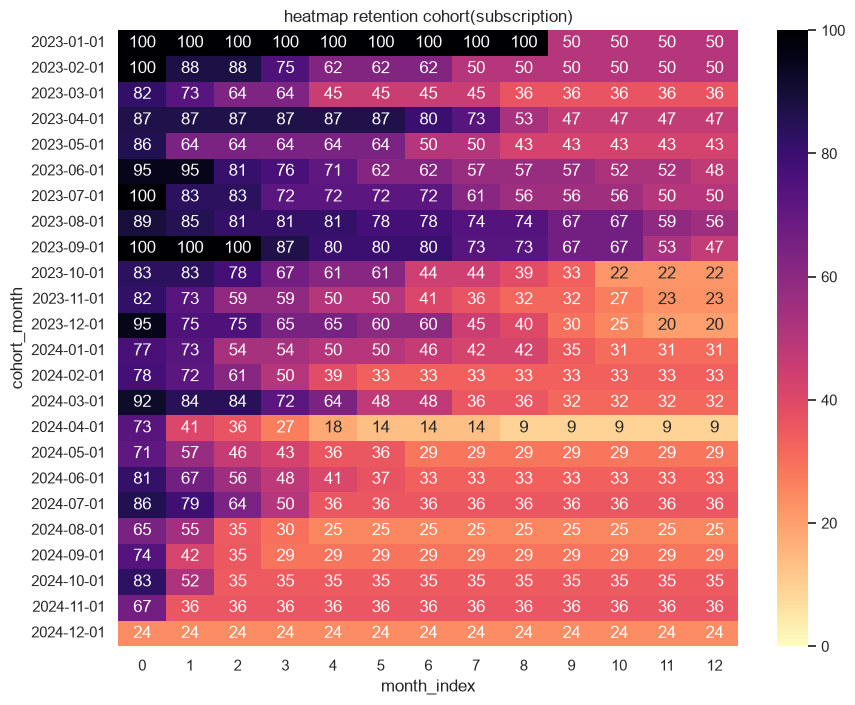

In [54]:
plt.figure(figsize=(10,8))
plt.title('heatmap retention cohort(subscription)')
sns.heatmap(data = pivot_subscription, vmin = 0, vmax = 100, cmap = 'magma_r', annot = True, fmt = '.0f')

- cohort rentention by subscription ini dihitung dari kapan pertama pengguna berlangganan hingga kapan pengguna itu melakukan churn pertama kali. Kalau bulan depan mereka langganan lagi mereka tetap tidak akan dihitung lagi di grafik ini. Untuk melihat seberapa betah pelanggan baru menggunakan aplikasi ini.
- Dapat dilihat bahwa terjadi perbedaan yang cukup signifikan pada angkatan 2023 dengan angkatan 2024. Pada angkatan 2023 terlihat warna yang masih gelap, artinya pengguna baru masih awet hingga berbulan-bulan hingga mereka akhirnya churn. Tapi masuk tahun 2024, warnanya langsung pudar kemerahan. Artinya, pelanggan baru di 2024 jauh lebih gampang kecewa dan langsung kabur tak lama setelah mencoba aplikasinya.
- Puncaknya adalah tahun 2024, dimana pengguna baru setelah daftar di bulan 12 pada bulan tersebut juga mereka churn


## support tickets

### tiket perbulan

In [65]:
support_sql = """

-- 13a. Volume ticket per bulan
SELECT
    strftime('%Y-%m', submitted_at) AS month,
    COUNT(*) AS ticket_count,
    ROUND(AVG(resolution_time_hours), 1) AS avg_resolution_hrs,
    ROUND(AVG(first_response_time_minutes), 1) AS avg_first_response_min,
    SUM(CASE WHEN escalation_flag = 'True' THEN 1 ELSE 0 END) AS escalations,
    ROUND(100.0 * SUM(CASE WHEN escalation_flag = 'True' THEN 1 ELSE 0 END) / COUNT(*), 1) AS escalation_rate_pct
FROM support_tickets
GROUP BY month
ORDER BY month;


"""

support_df1 = pd.read_sql(support_sql, conn)

In [66]:
support_df1

,month,ticket_count,avg_resolution_hrs,avg_first_response_min,escalations,escalation_rate_pct
0,2023-01,83,34.6,86.2,1,1.2
1,2023-02,59,35.9,76.4,4,6.8
2,2023-03,86,36.2,95.3,3,3.5
3,2023-04,91,36.4,89.0,6,6.6
4,2023-05,78,33.4,90.3,4,5.1
5,2023-06,82,37.7,93.7,2,2.4
6,2023-07,83,38.3,89.4,1,1.2
7,2023-08,96,33.9,82.8,3,3.1
8,2023-09,93,36.8,85.3,5,5.4
9,2023-10,75,38.3,97.3,4,5.3


In [67]:
support_df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   month                   24 non-null     str    
 1   ticket_count            24 non-null     int64  
 2   avg_resolution_hrs      24 non-null     float64
 3   avg_first_response_min  24 non-null     float64
 4   escalations             24 non-null     int64  
 5   escalation_rate_pct     24 non-null     float64
dtypes: float64(3), int64(2), str(1)
memory usage: 1.3 KB


In [68]:
support_df1.month = pd.to_datetime(support_df1.month)

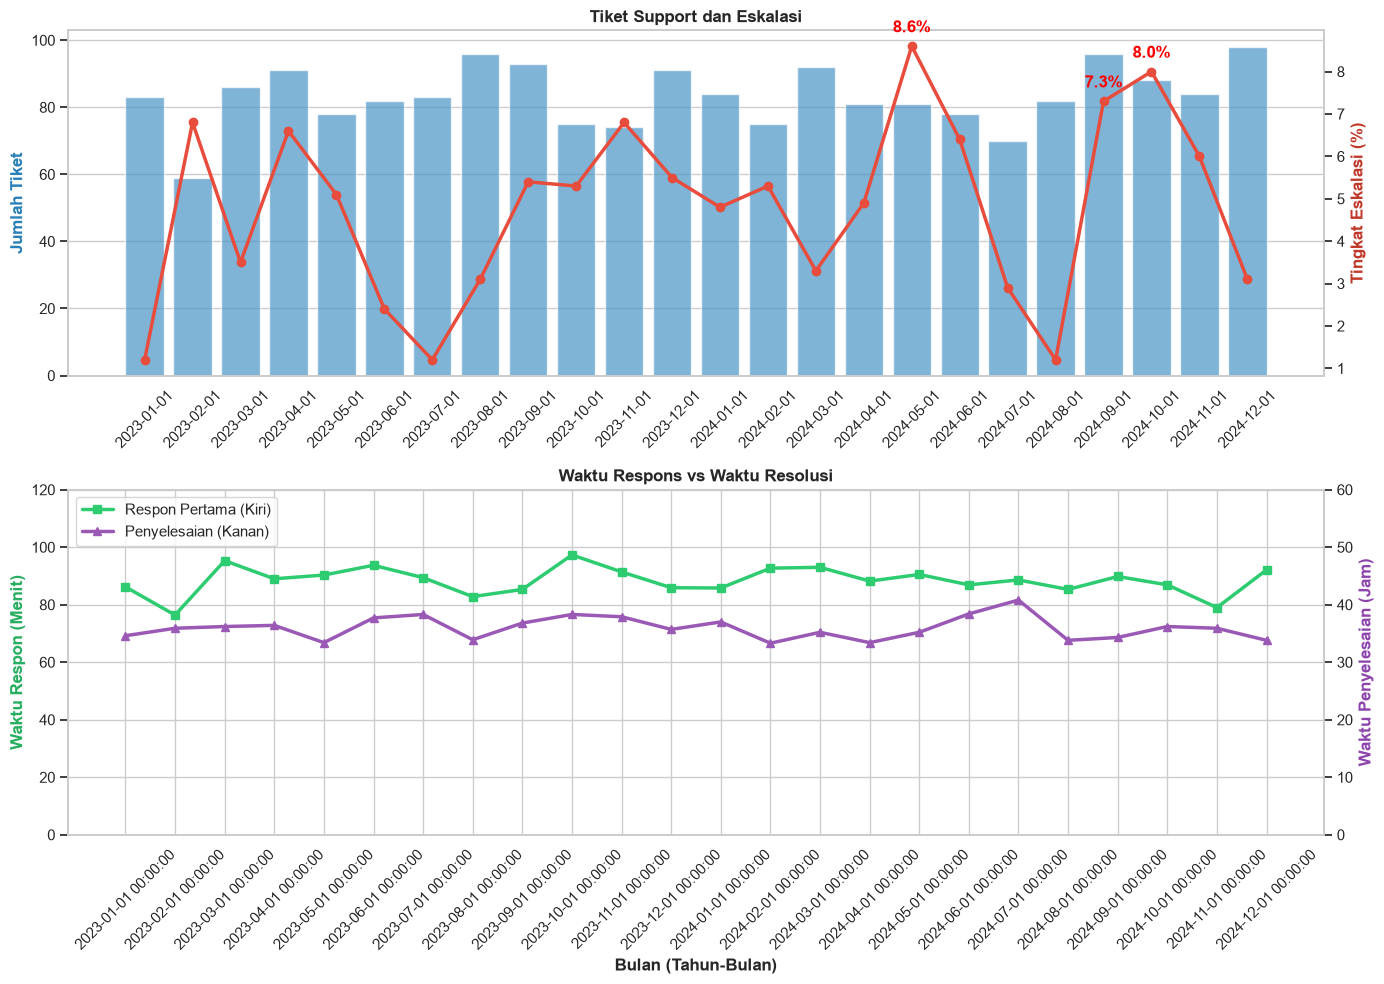

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pastikan matplotlib menggunakan style yang rapi
sns.set_theme(style="whitegrid")

# Trik anti-error: Buat indeks angka (0, 1, 2...) untuk sumbu X
x_indexes = np.arange(len(support_df1))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), dpi=100)

# =================================================================
# GRAFIK 1 (ATAS): Volume Tiket vs Tingkat Eskalasi
# =================================================================
ax1 = axes[0]
ax2 = ax1.twinx()

# Plot Bar (Otomatis memakai sumbu X kategori)
sns.barplot(data=support_df1, x='month', y='ticket_count', color='#3498db', ax=ax1, alpha=0.7)
ax1.set_ylabel('Jumlah Tiket', fontweight='bold', color='#2980b9')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)

# Plot Line (Menggunakan matplotlib biasa + x_indexes agar tidak bentrok)
ax2.plot(x_indexes, support_df1['escalation_rate_pct'], color='#e74c3c', marker='o', linewidth=2.5)
ax2.set_ylabel('Tingkat Eskalasi (%)', fontweight='bold', color='#c0392b')
ax2.grid(False) 

# Anotasi titik merah untuk eskalasi > 7%
for i, row in support_df1.iterrows():
    if row['escalation_rate_pct'] > 7.0: 
        ax2.annotate(f"{row['escalation_rate_pct']}%", 
                     xy=(i, row['escalation_rate_pct']), 
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', color='red', fontweight='bold')

ax1.set_title('Tiket Support dan Eskalasi', fontweight='bold')

# =================================================================
# GRAFIK 2 (BAWAH): Waktu Respon vs Waktu Resolusi
# =================================================================
ax3 = axes[1]
ax4 = ax3.twinx()

# Plot Garis menggunakan Matplotlib biasa agar sumbunya presisi
line1 = ax3.plot(x_indexes, support_df1['avg_first_response_min'], color='#2ecc71', marker='s', linewidth=2.5, label='Respon Pertama (Kiri)')
ax3.set_ylabel('Waktu Respon (Menit)', fontweight='bold', color='#27ae60')
ax3.set_xlabel('Bulan (Tahun-Bulan)', fontweight='bold')

# Pasang teks bulan (2023-01, dll) ke sumbu X di grafik bawah
ax3.set_xticks(x_indexes)
ax3.set_xticklabels(support_df1['month'], rotation=45)
ax3.set_ylim(0, 120)

# Plot Garis Resolusi
line2 = ax4.plot(x_indexes, support_df1['avg_resolution_hrs'], color='#9b59b6', marker='^', linewidth=2.5, label='Penyelesaian (Kanan)')
ax4.set_ylabel('Waktu Penyelesaian (Jam)', fontweight='bold', color='#8e44ad')
ax4.grid(False)
ax4.set_ylim(0, 60)

# Gabungkan kotak keterangan (Legend)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='upper left')

ax3.set_title('Waktu Respons vs Waktu Resolusi', fontweight='bold')

plt.tight_layout()
plt.show()



- ticket count / tiket untuk komplain pelanggan yang diperoleh tiap bulan ada di angka 70 hingga 90 an. tetapi tingkat eskalasi / masalah yang harus dilempar ke teknisi atau manajer mengalami lonjakan di bulan Mei 2024 (8.6%) serta September-Oktober 2024 (±8%). Dapat dikatakan bahwa terjadi masalah yang cukup rumit dalam produk yang digunakan pengguna sehingga harus memanggil ke teknisi

- meskipun pada 2024 tim dihadapkan dengan tingkat eskalasi tinggi, tetapi rata-rata waktu respon beserta rata- rata waktu resolusi cukup stabil. waktu respon di 80 menitan, dan waktu resolusi di 35 jam an.


### priority breakdown

In [70]:
support_sql2 = """
-- 13b. Breakdown by priority (uncomment to run separately)
 SELECT
     priority,
     COUNT(*) AS ticket_count,
     ROUND(AVG(resolution_time_hours), 1) AS avg_resolution_hrs,
     ROUND(AVG(first_response_time_minutes), 1) AS avg_first_response_min,
     ROUND(AVG(satisfaction_score), 2) AS avg_satisfaction
 FROM support_tickets
 GROUP BY priority
 ORDER BY CASE priority WHEN 'urgent' THEN 1 WHEN 'high' THEN 2 WHEN 'medium' THEN 3 ELSE 4 END;
"""
support_df2 = pd.read_sql(support_sql2, conn)

In [71]:
support_df2

,priority,ticket_count,avg_resolution_hrs,avg_first_response_min,avg_satisfaction
0,urgent,514,34.6,85.5,2.33
1,high,510,37.0,91.4,2.31
2,medium,491,35.6,85.9,2.34
3,low,485,36.3,91.2,2.38


C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\142592350.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=support_df2, x='priority', y='ticket_count', ax=axes[0,0], palette=priority_palette)
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\142592350.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=support_df2, x='priority', y='avg_resolution_hrs', ax=axes[0,1], palette=priority_palette)
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\142592350.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=suppo

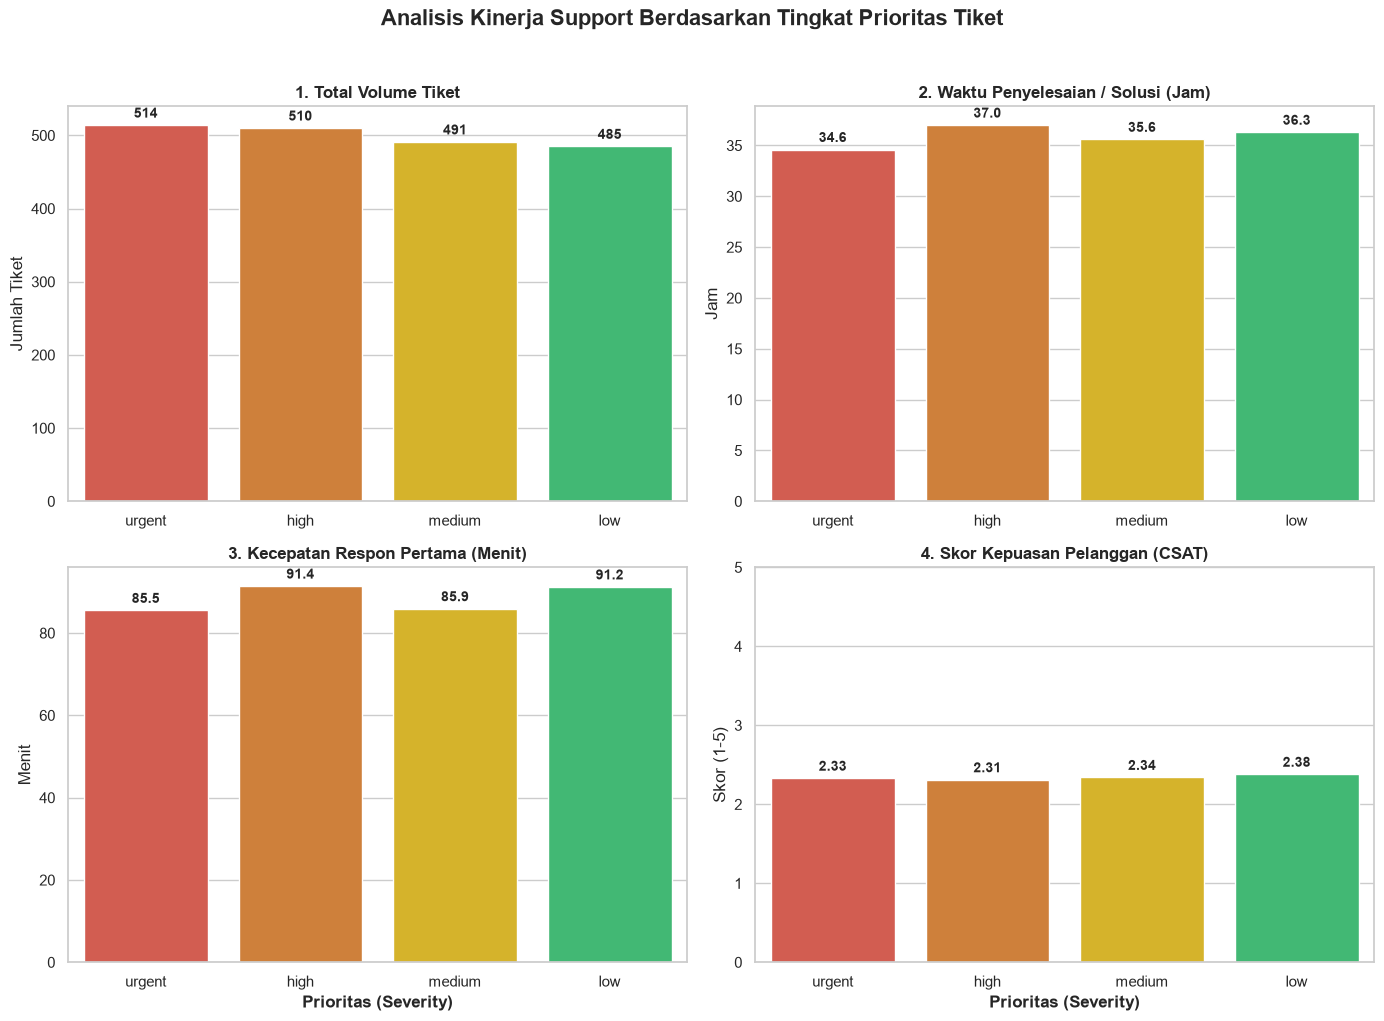

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan menggunakan tema yang bersih
sns.set_theme(style="whitegrid")

# Buat kamus warna berdasarkan level bahaya
priority_palette = {'urgent': '#e74c3c', 'high': '#e67e22', 'medium': '#f1c40f', 'low': '#2ecc71'}

# Siapkan kanvas 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
fig.suptitle('Analisis Kinerja Support Berdasarkan Tingkat Prioritas Tiket', fontsize=16, fontweight='bold', y=1.02)

# --- FUNGSI BANTUAN --- (Untuk menaruh angka di atas grafik batang otomatis)
def annotate_bars(ax, format_str='{:.1f}'):
    for p in ax.patches:
        ax.annotate(format_str.format(p.get_height()), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), 
                    textcoords='offset points', fontweight='bold', fontsize=10)

# ==========================================
# [0,0] Kiri Atas: Total Volume Tiket
# ==========================================
sns.barplot(data=support_df2, x='priority', y='ticket_count', ax=axes[0,0], palette=priority_palette)
axes[0,0].set_title('1. Total Volume Tiket', fontweight='bold')
axes[0,0].set_ylabel('Jumlah Tiket')
axes[0,0].set_xlabel('')
annotate_bars(axes[0,0], '{:.0f}')

# ==========================================
# [0,1] Kanan Atas: Rata-rata Waktu Solusi
# ==========================================
sns.barplot(data=support_df2, x='priority', y='avg_resolution_hrs', ax=axes[0,1], palette=priority_palette)
axes[0,1].set_title('2. Waktu Penyelesaian / Solusi (Jam)', fontweight='bold')
axes[0,1].set_ylabel('Jam')
axes[0,1].set_xlabel('')
annotate_bars(axes[0,1], '{:.1f}')

# ==========================================
# [1,0] Kiri Bawah: Rata-rata Waktu Respon
# ==========================================
sns.barplot(data=support_df2, x='priority', y='avg_first_response_min', ax=axes[1,0], palette=priority_palette)
axes[1,0].set_title('3. Kecepatan Respon Pertama (Menit)', fontweight='bold')
axes[1,0].set_ylabel('Menit')
axes[1,0].set_xlabel('Prioritas (Severity)', fontweight='bold')
annotate_bars(axes[1,0], '{:.1f}')

# ==========================================
# [1,1] Kanan Bawah: Rata-rata CSAT (Skor Kepuasan)
# ==========================================
sns.barplot(data=support_df2, x='priority', y='avg_satisfaction', ax=axes[1,1], palette=priority_palette)
axes[1,1].set_title('4. Skor Kepuasan Pelanggan (CSAT)', fontweight='bold')
axes[1,1].set_ylabel('Skor (1-5)')
axes[1,1].set_xlabel('Prioritas (Severity)', fontweight='bold')
axes[1,1].set_ylim(0, 5) # Maksimal kepuasan adalah bintang 5
annotate_bars(axes[1,1], '{:.2f}')

plt.tight_layout()
plt.show()


- masalah urgent disini sangat banyak bahkan melebihi tingkat masalah yang prioritasnya lebih rendah, seharusnya masalah yang urgent lebih sedikit. terdapat 2 kemungkinan terjadinya ticket count dengan tingkat prioritas urgent :

-- Pelanggan bisa memilih sendiri label "Urgent", sehingga mereka memanipulasi sistem agar tiketnya cepat 

-- dibalas (padahal cuma masalah sepele).
Atau memang kualitas aplikasi RavenStack sangat hancur, sehingga setiap kali ada error, dampaknya selalu fatal bagi bisnis pelanggan.

- kepuasan pelanggan merata dari setiap tingkat prioritas tiket dari yang low hingga urgent, hal ini dapat disebabkan waktu resolusi yang rata-rata dilakukan dalam 1,5 hari.

- perusahaan harus bisa menyortir mana masalah urgent dan harus segera diselesaikan 

### MRR

In [73]:
import matplotlib.ticker as ticker

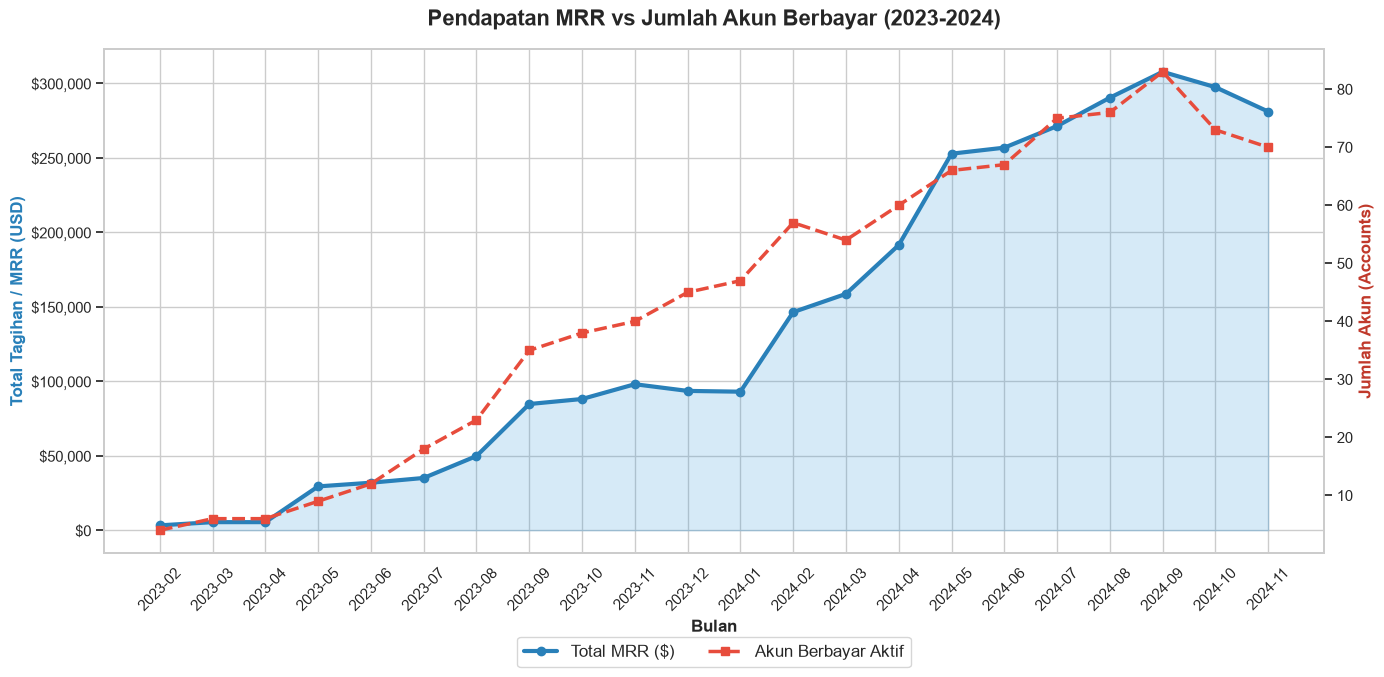

In [74]:
# 2. Jalankan Query MRR (Versi End-of-Month Snapshot yang Super Ketat)
mrr_sql = """
WITH RECURSIVE month_series(m) AS (
    SELECT '2023-01-01'
    UNION ALL
    SELECT date(m, '+1 month') FROM month_series
    WHERE m < (SELECT MAX(start_date) FROM subscriptions)
)
SELECT
    ms.m AS month,
    ROUND(SUM(s.mrr_amount), 2) AS total_mrr,
    COUNT(DISTINCT CASE WHEN s.mrr_amount > 0 THEN s.account_id END) AS active_paying_accounts
FROM month_series ms
JOIN subscriptions s
    -- Syarat 1: Mulai langganan sebelum akhir bulan tersebut
    ON date(s.start_date) <= date(ms.m, '+1 month', '-1 day')
    -- Syarat 2: Belum churn, ATAU churn-nya terjadi SETELAH akhir bulan tersebut
    AND (s.end_date IS NULL OR date(s.end_date) > date(ms.m, '+1 month', '-1 day'))
GROUP BY ms.m
ORDER BY ms.m;
"""

# Eksekusi SQL dan simpan ke variabel df_mrr
df_mrr = pd.read_sql(mrr_sql, conn)

# 3. Visualisasi Grafik
sns.set_theme(style="whitegrid")

# Ubah format string tanggal SQL menjadi Bulan-Tahun ('2023-01')
df_mrr['month_label'] = pd.to_datetime(df_mrr['month']).dt.strftime('%Y-%m')

# Buat Kanvas
fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)

# =================================================================
# GRAFIK UTAMA (Sumbu Kiri): Total MRR per Bulan
# =================================================================
ax1.fill_between(df_mrr['month_label'], df_mrr['total_mrr'], color='#3498db', alpha=0.2)
ax1.plot(df_mrr['month_label'], df_mrr['total_mrr'], color='#2980b9', marker='o', linewidth=3, label='Total MRR ($)')

ax1.set_xlabel('Bulan', fontweight='bold', fontsize=12)
ax1.set_ylabel('Total Tagihan / MRR (USD)', fontweight='bold', color='#2980b9', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)

# =================================================================
# GRAFIK KEDUA (Sumbu Kanan): Jumlah Akun Berbayar Aktif
# =================================================================
ax2 = ax1.twinx()
ax2.plot(df_mrr['month_label'], df_mrr['active_paying_accounts'], color='#e74c3c', marker='s', linestyle='--', linewidth=2.5, label='Akun Berbayar Aktif')

ax2.set_ylabel('Jumlah Akun (Accounts)', fontweight='bold', color='#c0392b', fontsize=12)
ax2.grid(False)

# =================================================================
# JUDUL & LEGEND
# =================================================================
plt.title('Pendapatan MRR vs Jumlah Akun Berbayar (2023-2024)', fontsize=16, fontweight='bold', y=1.03)

# Gabungkan kotak Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=12)

plt.tight_layout()
plt.show()


- Di pertengahan 2024, kualitas aplikasi menurun drastis dipenuhi bug parah (Terbukti dari Tingkat Eskalasi Support yang meroket).
- Pelanggan baru menjadi Zombie Users karena malas memakai aplikasi yang rusak (Terbukti dari bolongnya Engagement Cohort).
- Pelanggan merasa tertipu dan membatalkan langganan di bulan pertama (Terbukti dari merahnya Subscription Cohort di tahun 2024).
- Puncaknya, akumulasi dari semua kekecewaan pelanggan itu kini menghancurkan Total Pendapatan MRR perusahaan di akhir 2024 (Grafik di atas).

# cek churn vs signups

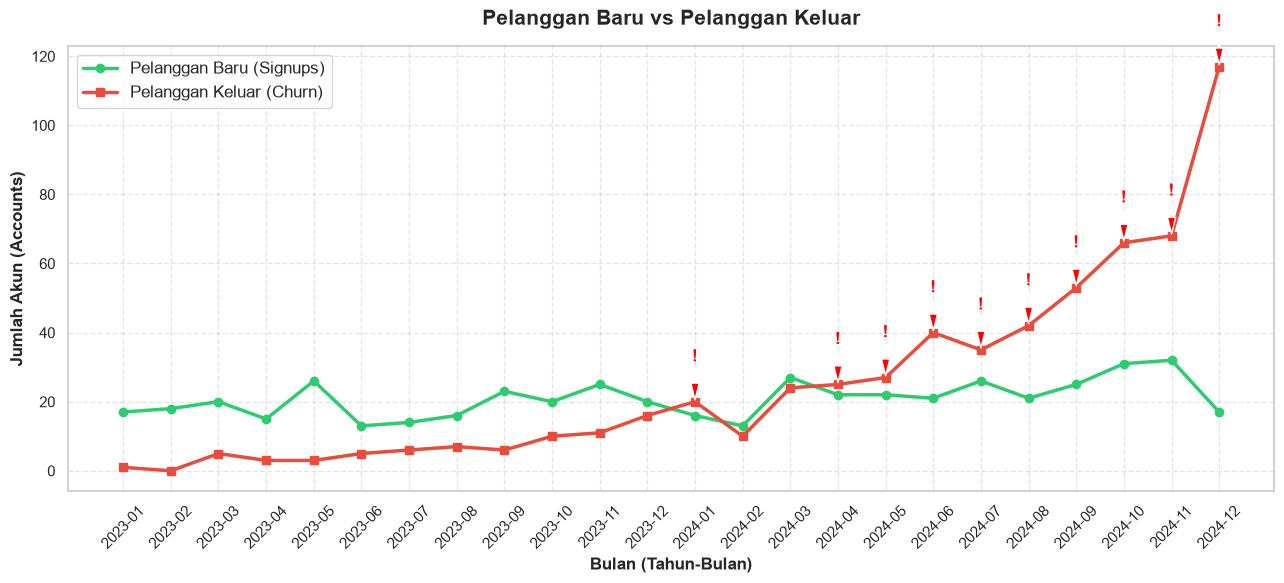

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_acc = pd.read_csv('ravenstack_accounts.csv')
df_churn = pd.read_csv('ravenstack_churn_events.csv')

# 2. Siapkan data Tanggal (Ubah string ke format Datetime)
df_acc['signup_date'] = pd.to_datetime(df_acc['signup_date'])
df_churn['churn_date'] = pd.to_datetime(df_churn['churn_date'])

# Ambil periode Tahun-Bulan (YYYY-MM)
df_acc['signup_month'] = df_acc['signup_date'].dt.to_period('M')
df_churn['churn_month'] = df_churn['churn_date'].dt.to_period('M')

# 3. Hitung Total per Bulan
# Signups (Pelanggan Masuk)
monthly_signups = df_acc.groupby('signup_month').size().reset_index(name='new_signups')
# Churns (Pelanggan Keluar)
monthly_churns = df_churn.groupby('churn_month').size().reset_index(name='total_churns')

# Gabungkan kedua data berdasarkan bulan
trend_df = pd.merge(monthly_signups, monthly_churns, left_on='signup_month', right_on='churn_month', how='outer')
trend_df['month'] = trend_df['signup_month'].combine_first(trend_df['churn_month'])
trend_df = trend_df.drop(['signup_month', 'churn_month'], axis=1).fillna(0) # Isi 0 jika tidak ada kejadian di bulan itu
trend_df = trend_df.sort_values('month')

# Konversi kembali format bulan ke string untuk Matplotlib
trend_df['month_str'] = trend_df['month'].astype(str)

# ==========================================
# 4. VISUALISASI TREND LINE (TIME-SERIES)
# ==========================================
plt.figure(figsize=(13, 6), dpi=100)

# Plot Garis Signups (Warna Hijau)
plt.plot(trend_df['month_str'], trend_df['new_signups'], marker='o', color='#2ecc71', linewidth=2.5, label='Pelanggan Baru (Signups)')

# Plot Garis Churn (Warna Merah)
plt.plot(trend_df['month_str'], trend_df['total_churns'], marker='s', color='#e74c3c', linewidth=2.5, label='Pelanggan Keluar (Churn)')

# Estetika Grafik
plt.title('Pelanggan Baru vs Pelanggan Keluar', fontsize=15, fontweight='bold', y=1.03)
plt.xlabel('Bulan (Tahun-Bulan)', fontweight='bold')
plt.ylabel('Jumlah Akun (Accounts)', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12, loc='upper left')

# Deteksi Otomatis & Anotasi: Bulan di mana Churn melebihi Signups (Bahaya!)
for i in range(len(trend_df)):
    if trend_df['total_churns'].iloc[i] > trend_df['new_signups'].iloc[i]:
        plt.annotate('!', 
                     xy=(i, trend_df['total_churns'].iloc[i]), 
                     xytext=(i, trend_df['total_churns'].iloc[i] + (trend_df['total_churns'].max()*0.1)),
                     ha='center', color='red', fontweight='bold',
                     arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6))

plt.tight_layout()
plt.show()


- di Awal 2024 Mulai bulan Januari 2024 banyak pelanggan yang membatalkan langganan (Churn) berhasil menyalip jumlah pendaftar baru (Signups).

- Pendaftar baru (garis hijau) sangat stagnan di angka belasan akun, sementara lonjakan pelanggan yang kabur (garis merah) menembus angka 110+ akun. Ini berarti kecepatan kebocoran pelanggan 6x lipat lebih cepat dibandingkan kecepatan mendatangkan pelanggan baru.

- Garis hijau (Pendaftar Baru) terlihat sangat datar sepanjang tahun 2023 hingga 2024 (hanya stabil di kisaran 15-30 akun per bulan)

# Accounts

C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\1465274826.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_acc, y='industry', palette='Blues_r', ax=axes[0,0], order=order_industry)
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\1465274826.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_acc, x='country', palette='Greens_r', ax=axes[0,1], order=order_country)
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\1465274826.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_acc, x='referral

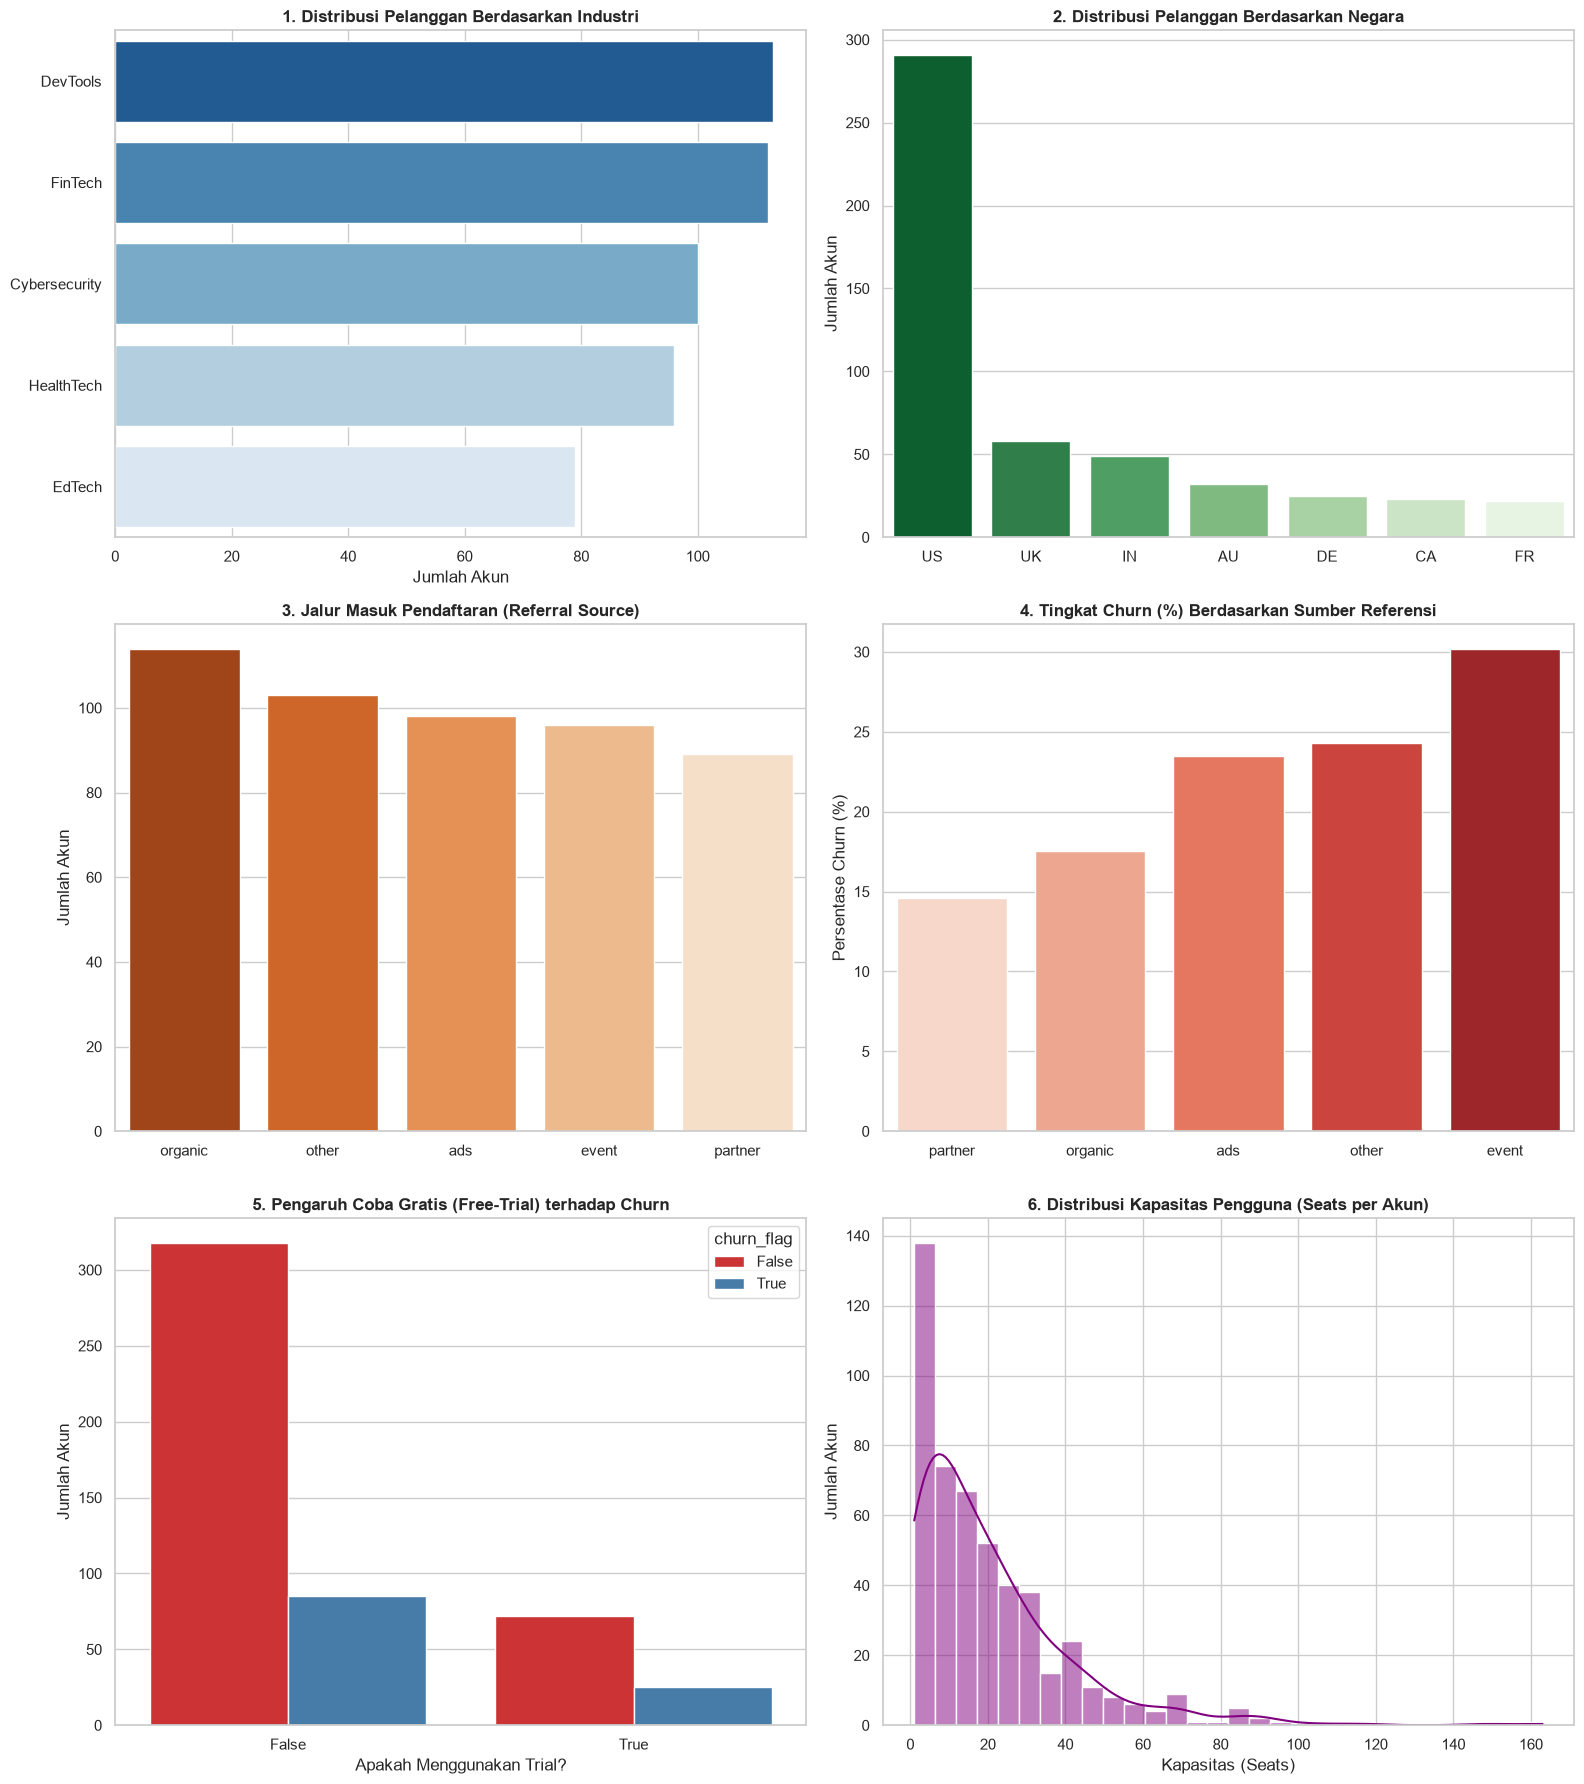

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data Accounts
df_acc = pd.read_csv('ravenstack_accounts.csv')

# Buat Kanvas Besar (Grid 3 baris x 2 kolom)
fig, axes = plt.subplots(3, 2, figsize=(16, 18), dpi=100)
sns.set_theme(style="whitegrid")

# =======================================================
# 1. Distribusi Industri (Siapa target pasar utama?)
# =======================================================
order_industry = df_acc['industry'].value_counts().index
sns.countplot(data=df_acc, y='industry', palette='Blues_r', ax=axes[0,0], order=order_industry)
axes[0,0].set_title('1. Distribusi Pelanggan Berdasarkan Industri', fontweight='bold')
axes[0,0].set_xlabel('Jumlah Akun')
axes[0,0].set_ylabel('')

# =======================================================
# 2. Distribusi Negara (Dari mana asal pelanggan?)
# =======================================================
order_country = df_acc['country'].value_counts().index
sns.countplot(data=df_acc, x='country', palette='Greens_r', ax=axes[0,1], order=order_country)
axes[0,1].set_title('2. Distribusi Pelanggan Berdasarkan Negara', fontweight='bold')
axes[0,1].set_ylabel('Jumlah Akun')
axes[0,1].set_xlabel('')

# =======================================================
# 3. Sumber Referensi (Darimana mereka tahu aplikasi ini?)
# =======================================================
order_referral = df_acc['referral_source'].value_counts().index
sns.countplot(data=df_acc, x='referral_source', palette='Oranges_r', ax=axes[1,0], order=order_referral)
axes[1,0].set_title('3. Jalur Masuk Pendaftaran (Referral Source)', fontweight='bold')
axes[1,0].set_ylabel('Jumlah Akun')
axes[1,0].set_xlabel('')

# =======================================================
# 4. Pengaruh Jalur Masuk (Referral) terhadap Churn
# =======================================================
churn_ref = df_acc.groupby('referral_source')['churn_flag'].mean().sort_values() * 100
sns.barplot(x=churn_ref.index, y=churn_ref.values, palette='Reds', ax=axes[1,1])
axes[1,1].set_title('4. Tingkat Churn (%) Berdasarkan Sumber Referensi', fontweight='bold')
axes[1,1].set_ylabel('Persentase Churn (%)')
axes[1,1].set_xlabel('')

# =======================================================
# 5. Apakah pengguna Trial (Coba Gratis) lebih mudah Churn?
# =======================================================
sns.countplot(data=df_acc, x='is_trial', hue='churn_flag', palette='Set1', ax=axes[2,0])
axes[2,0].set_title('5. Pengaruh Coba Gratis (Free-Trial) terhadap Churn', fontweight='bold')
axes[2,0].set_ylabel('Jumlah Akun')
axes[2,0].set_xlabel('Apakah Menggunakan Trial?')

# =======================================================
# 6. Distribusi Kapasitas (Seats) yang Diminta
# =======================================================
sns.histplot(data=df_acc, x='seats', bins=30, color='purple', ax=axes[2,1], kde=True)
axes[2,1].set_title('6. Distribusi Kapasitas Pengguna (Seats per Akun)', fontweight='bold')
axes[2,1].set_ylabel('Jumlah Akun')
axes[2,1].set_xlabel('Kapasitas (Seats)')

plt.tight_layout()
plt.show()


- perusahaan yang merupakan pelanggan utama RavenStack adalah dari industri DevTools dan negara yang terbesar adalah Amerika

- Grafik 3 dan 4 membongkar kegagalan strategi pemasaran perusahaan. Meskipun pendaftar dari jalur Event (Pameran/Seminar) jumlahnya cukup banyak, tingkat Churn mereka adalah yang terburuk (mencapai 30%).

- Pada Grafik 5, perbandingan antara balok biru (Churn) dan balok merah (Retained) terlihat proporsional, baik pada kelompok yang memakai Free-Trial maupun yang tidak.

- Grafik ke 6 memiliki bentuk Right-Skewed (menjulur ke kanan). Artinya, mayoritas absolut pelanggan RavenStack (hampir 140 akun) hanya membeli kapasitas seats yang sangat kecil (antara 1 hingga 10 pengguna per akun). Ini menunjukkan bahwa pengguna utama aplikasi ini adalah UMKM (Small-to-Medium Businesses) atau tim-tim kecil di dalam sebuah departemen.

- Di ujung kanan grafik, terlihat ada segelintir kecil perusahaan raksasa yang membeli kapasitas sangat besar (dari 80 hingga 160 seats). . Meskipun jumlah perusahaannya sangat sedikit (bisa dihitung jari), mereka menyumbangkan uang yang sangat masif karena tagihan SaaS dihitung per-kepala (per-seat).

- Jika RavenStack kehilangan 10 pelanggan kecil di sebelah kiri grafik, mungkin kerugiannya tidak terlalu terasa. TAPI, jika SATU saja pelanggan berkapasitas 160 seats di ujung kanan ini kecewa (akibat bug sistem) dan memutuskan untuk kabur (Churn), maka grafik pendapatan (MRR) RavenStack akan langsung anjlok parah dalam sekejap.

In [79]:
import pandas as pd

# Load Data
df_subs = pd.read_csv('ravenstack_subscriptions.csv')

# Ambil langganan aktif
active_subs = df_subs[df_subs['churn_flag'] == False]

# Hitung Total MRR per Akun lalu urutkan dari terbesar
acc_spend = active_subs.groupby('account_id')['mrr_amount'].sum().reset_index()
acc_spend_sorted = acc_spend.sort_values('mrr_amount', ascending=False)

# Hitung Total Keseluruhan vs Top 10
total_mrr = acc_spend['mrr_amount'].sum()
top_10_mrr = acc_spend_sorted.head(10)['mrr_amount'].sum()

# Hitung Persentase
persentase = (top_10_mrr / total_mrr) * 100

print("="*65)
print("KONTRIBUSI PENDAPATAN DARI TOP 10 'SULTAN'")
print("="*65)
print(f"Total MRR Aktif Seluruh Pelanggan : ${total_mrr:,.2f}")
print(f"Total MRR dari Top 10 Pelanggan   : ${top_10_mrr:,.2f}")
print(f"Persentase Kontribusi Top 10      : {persentase:.2f}%")

# BONUS: Berapa banyak Sultan yang dibutuhkan untuk meraup 50% MRR?
acc_spend_sorted['cumulative_mrr'] = acc_spend_sorted['mrr_amount'].cumsum()
acc_spend_sorted['cumulative_pct'] = (acc_spend_sorted['cumulative_mrr'] / total_mrr) * 100
top_50_pct = acc_spend_sorted[acc_spend_sorted['cumulative_pct'] <= 50]

print(f"\n Dibutuhkan HANYA {len(top_50_pct)} pelanggan teratas untuk menyumbang 50% dari seluruh pendapatan perusahaan!")


KONTRIBUSI PENDAPATAN DARI TOP 10 'SULTAN'
Total MRR Aktif Seluruh Pelanggan : $10,159,608.00
Total MRR dari Top 10 Pelanggan   : $858,309.00
Persentase Kontribusi Top 10      : 8.45%

 Dibutuhkan HANYA 124 pelanggan teratas untuk menyumbang 50% dari seluruh pendapatan perusahaan!


# Churn Rate

Overall Churn Rate: 22.00%

2. CHURN RATE BERDASARKAN PLAN TIER
 plan_tier  total_accounts  churned_accounts  churn_rate_pct  avg_seats
Enterprise             154                34           22.08  19.688312
     Basic             168                37           22.02  22.005952
       Pro             178                39           21.91  19.949438

3. CHURN RATE BERDASARKAN STATUS TRIAL
 is_trial  total_accounts  churned_accounts  churn_rate_pct  avg_seats
     True              97                25           25.77  21.113402
    False             403                85           21.09  20.426799

4. CHURN RATE BERDASARKAN REFERRAL SOURCE
referral_source  total_accounts  churned_accounts  churn_rate_pct  avg_seats
          event              96                29           30.21  21.239583
          other             103                25           24.27  21.815534
            ads              98                23           23.47  18.959184
        organic             114             

C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\155080149.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tier, x='plan_tier', y='churn_rate_pct', ax=axes[0, 0], palette='Blues_r')
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\155080149.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_trial, x='is_trial', y='churn_rate_pct', ax=axes[0, 1], palette='Oranges_r')
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\155080149.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 1].set_xticklabels(['Paid / Converted', 'In Trial']

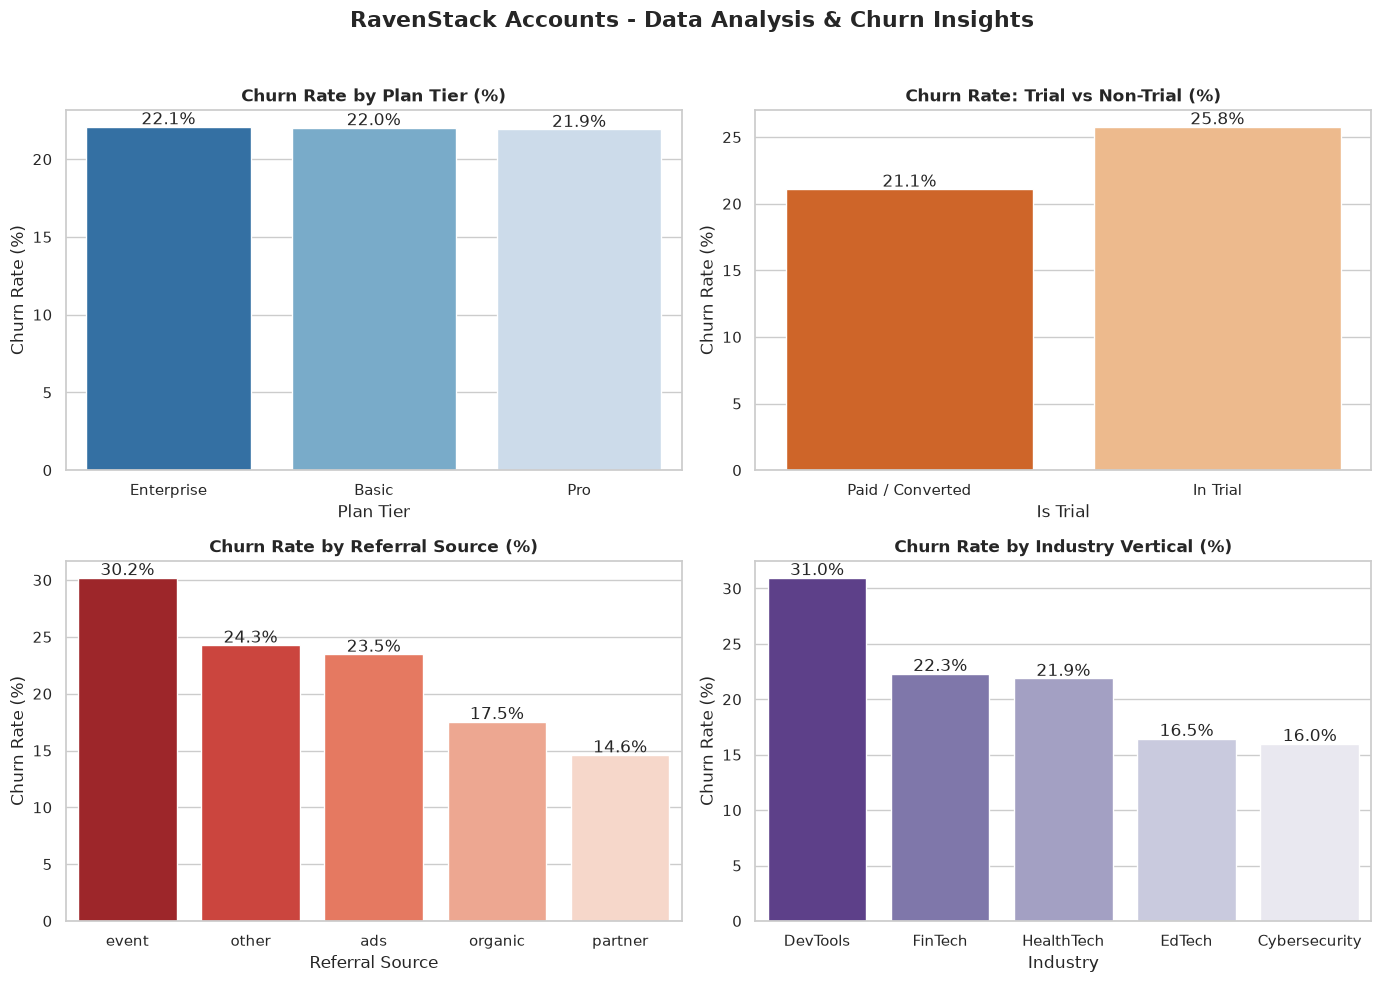

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset Accounts
df_accounts = pd.read_csv('ravenstack_accounts.csv')

# Visual styling setup
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print(f"Overall Churn Rate: {df_accounts['churn_flag'].mean()*100:.2f}%\n")


# 2. Fungsi Helper untuk Agregasi Churn
def analyze_churn(df, group_col):
    result = df.groupby(group_col).agg(
        total_accounts=('account_id', 'count'),
        churned_accounts=('churn_flag', 'sum'),
        churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
        avg_seats=('seats', 'mean')
    ).reset_index().sort_values(by='churn_rate_pct', ascending=False)
    return result

print("="*60)
print("2. CHURN RATE BERDASARKAN PLAN TIER")
print("="*60)
df_tier = analyze_churn(df_accounts, 'plan_tier')
print(df_tier.to_string(index=False))

print("\n" + "="*60)
print("3. CHURN RATE BERDASARKAN STATUS TRIAL")
print("="*60)
df_trial = analyze_churn(df_accounts, 'is_trial')
print(df_trial.to_string(index=False))

print("\n" + "="*60)
print("4. CHURN RATE BERDASARKAN REFERRAL SOURCE")
print("="*60)
df_ref = analyze_churn(df_accounts, 'referral_source')
print(df_ref.to_string(index=False))

print("\n" + "="*60)
print("5. CHURN RATE BERDASARKAN SEKTOR INDUSTRI")
print("="*60)
df_ind = analyze_churn(df_accounts, 'industry')
print(df_ind.to_string(index=False))


# 3. Visualisasi Grafik (Dashboard Insights)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RavenStack Accounts - Data Analysis & Churn Insights', fontsize=16, fontweight='bold')

# Chart 1: Churn Rate by Plan Tier
sns.barplot(data=df_tier, x='plan_tier', y='churn_rate_pct', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Churn Rate by Plan Tier (%)', fontweight='bold')
axes[0, 0].set_ylabel('Churn Rate (%)')
axes[0, 0].set_xlabel('Plan Tier')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Chart 2: Churn Rate by Trial Status
sns.barplot(data=df_trial, x='is_trial', y='churn_rate_pct', ax=axes[0, 1], palette='Oranges_r')
axes[0, 1].set_title('Churn Rate: Trial vs Non-Trial (%)', fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Is Trial')
axes[0, 1].set_xticklabels(['Paid / Converted', 'In Trial'])
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Chart 3: Churn Rate by Referral Source
sns.barplot(data=df_ref, x='referral_source', y='churn_rate_pct', ax=axes[1, 0], palette='Reds_r')
axes[1, 0].set_title('Churn Rate by Referral Source (%)', fontweight='bold')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].set_xlabel('Referral Source')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Chart 4: Churn Rate by Industry
sns.barplot(data=df_ind, x='industry', y='churn_rate_pct', ax=axes[1, 1], palette='Purples_r')
axes[1, 1].set_title('Churn Rate by Industry Vertical (%)', fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_xlabel('Industry')
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


- Harga plan tier tidak jadi masalah karena tingkat churn pada tiap tier sama di angka kurang lebih 22%.
- DevTools memiliki tingkat Churn terburuk,  perusahaan DevTools diisi oleh para Software Engineer yang memiliki standar teknis yang sangat tinggi dan TIDAK ADA TOLERANSI terhadap software yang lambat, penuh bug, atau sering error. Sebaliknya, industri non-teknis seperti EdTech jauh lebih pemaaf.
- Kembali terkonfirmasi dengan angka pasti: Mengakuisisi pelanggan melalui pameran (Event) adalah pemborosan fatal dengan risiko pelanggan kabur mencapai 30%. Sebaliknya, pelanggan yang datang dari kemitraan bisnis (Partner) adalah pelanggan bergaransi mutu dengan tingkat kabur terendah (hanya 14.6%).

C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\3250057204.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=country_stat_sorted, x='churn_rate', y='country', palette='Reds_r')


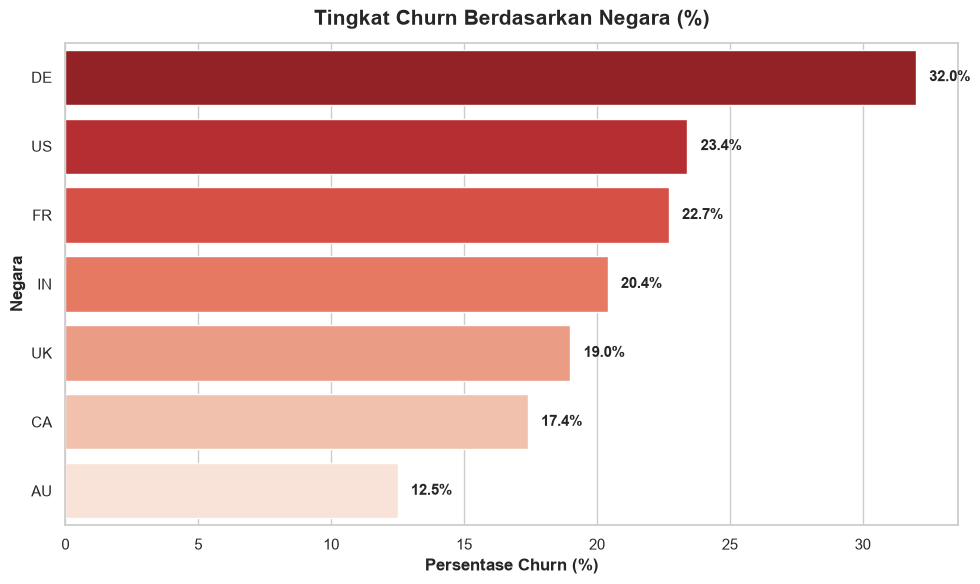

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Buat Kanvas untuk 1 Grafik Saja
plt.figure(figsize=(10, 6), dpi=100)
sns.set_theme(style="whitegrid")

# ============================================================
# GRAFIK 1: Churn Rate by Country
# ============================================================
# Urutkan berdasarkan churn rate tertinggi
country_stat_sorted = country_stat.sort_values('churn_rate', ascending=False).reset_index()

# Buat Barplot Horizontal
ax = sns.barplot(data=country_stat_sorted, x='churn_rate', y='country', palette='Reds_r')

plt.title('Tingkat Churn Berdasarkan Negara (%)', fontweight='bold', fontsize=15, y=1.02)
plt.xlabel('Persentase Churn (%)', fontweight='bold')
plt.ylabel('Negara', fontweight='bold')

# Tambahkan label angka di ujung bar
for p in ax.patches:
    ax.annotate(f"{p.get_width()}%", 
                (p.get_width() + 0.5, p.get_y() + p.get_height()/2.), 
                va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


DE adalah negara dengan tingkat churn paling tinggi.

Pendarahan Finansial di Markas Utama (US) Meskipun secara persentase Amerika Serikat (23.4%) berada di urutan kedua, secara dampak finansial, ini adalah bencana terbesar. Dari grafik distribusi demografi sebelumnya, kita tahu bahwa AS menyumbang mayoritas absolut (hampir 300 akun) dari total pelanggan RavenStack. Kehilangan 23% pelanggan dari "kolam" terbesar inilah yang menjadi penyebab utama runtuhnya grafik Total Pendapatan (MRR) perusahaan di akhir tahun 2024.

Peluang di Pasar Australia (AU) Di sisi lain, pelanggan dari Australia terbukti sebagai kelompok yang paling setia dan sabar, dengan tingkat kabur terendah (hanya 12.5%). 

C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\723782878.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right')
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\723782878.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=df_seats, x='seat_category', y='churn_pct', ax=axes[0, 1], palette='crest')
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\723782878.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(data=df_country, x='country', y='total_accounts', ax

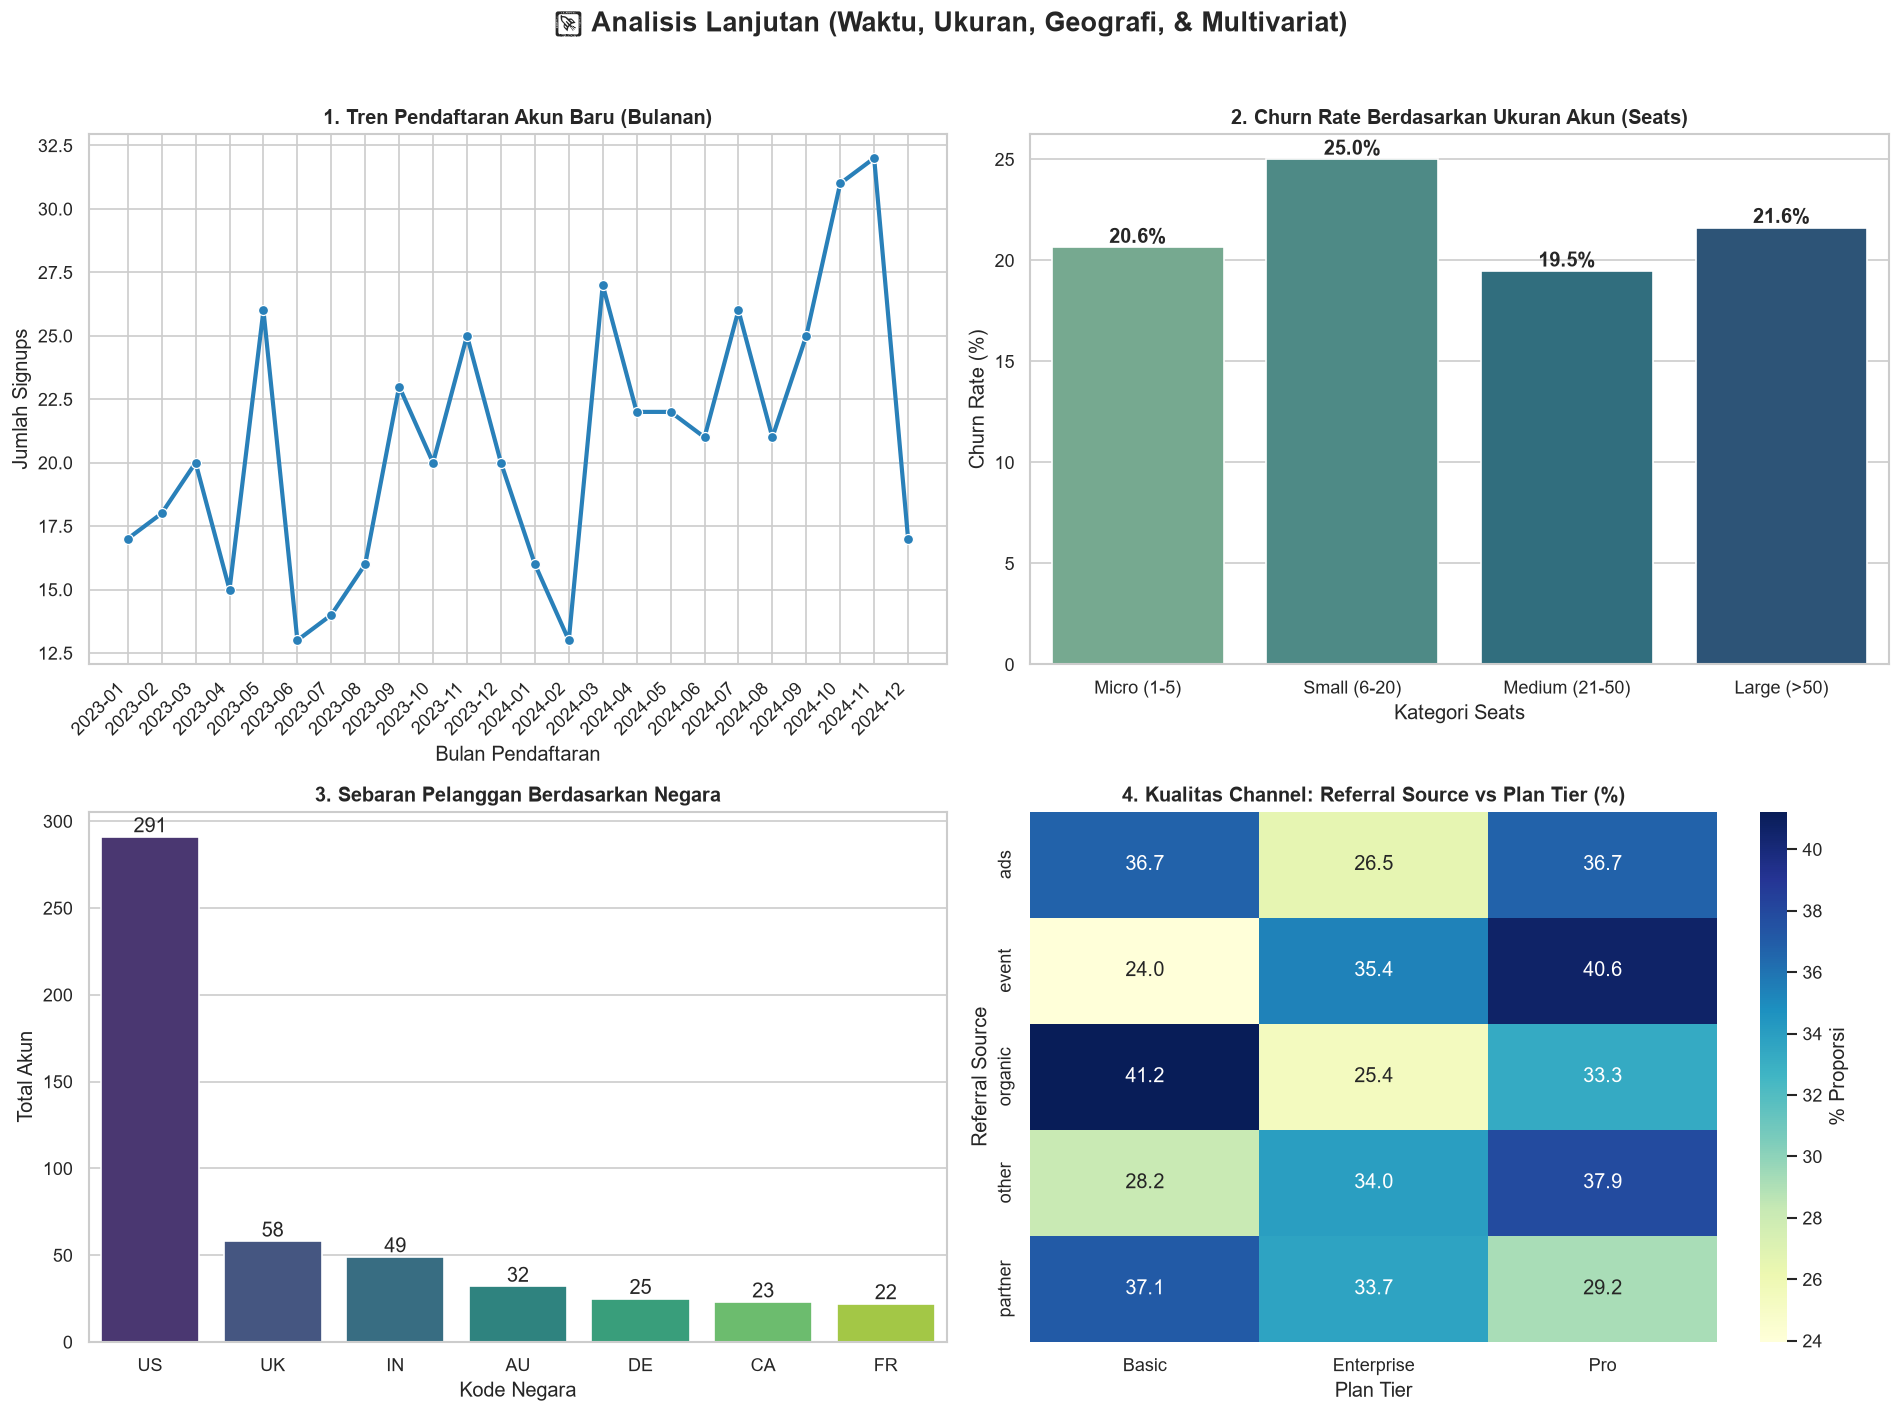

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# df_accounts = pd.read_csv('ravenstack_accounts.csv')

fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=120)
fig.suptitle('🚀 Analisis Lanjutan (Waktu, Ukuran, Geografi, & Multivariat)', fontsize=16, fontweight='bold', y=0.98)

# -------------------------------------------------------------
# 1. Tren Akuisisi Bulanan (Berdasarkan signup_date)
# -------------------------------------------------------------
df_accounts['signup_month'] = pd.to_datetime(df_accounts['signup_date']).dt.to_period('M').astype(str)
df_trend = df_accounts.groupby('signup_month').size().reset_index(name='signups')
df_trend = df_trend.sort_values('signup_month')

sns.lineplot(data=df_trend, x='signup_month', y='signups', marker='o', ax=axes[0, 0], color='#2980b9', linewidth=2.5)
axes[0, 0].set_title('1. Tren Pendaftaran Akun Baru (Bulanan)', fontweight='bold')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right')
axes[0, 0].set_ylabel('Jumlah Signups')
axes[0, 0].set_xlabel('Bulan Pendaftaran')

# -------------------------------------------------------------
# 2. Churn Rate Berdasarkan Ukuran Akun (Binned Seats)
# -------------------------------------------------------------
# Membuat kelompok (bins) untuk jumlah seats
bins = [0, 5, 20, 50, df_accounts['seats'].max()]
labels = ['Micro (1-5)', 'Small (6-20)', 'Medium (21-50)', 'Large (>50)']
df_accounts['seat_category'] = pd.cut(df_accounts['seats'], bins=bins, labels=labels)

df_seats = df_accounts.groupby('seat_category')['churn_flag'].mean().reset_index()
df_seats['churn_pct'] = df_seats['churn_flag'] * 100

ax2 = sns.barplot(data=df_seats, x='seat_category', y='churn_pct', ax=axes[0, 1], palette='crest')
axes[0, 1].set_title('2. Churn Rate Berdasarkan Ukuran Akun (Seats)', fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Kategori Seats')
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold')

# -------------------------------------------------------------
# 3. Distribusi Geografis (Top Negara & Volume)
# -------------------------------------------------------------
df_country = df_accounts['country'].value_counts().reset_index()
df_country.columns = ['country', 'total_accounts']

ax3 = sns.barplot(data=df_country, x='country', y='total_accounts', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('3. Sebaran Pelanggan Berdasarkan Negara', fontweight='bold')
axes[1, 0].set_ylabel('Total Akun')
axes[1, 0].set_xlabel('Kode Negara')
for p in ax3.patches:
    ax3.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 6), textcoords='offset points')

# -------------------------------------------------------------
# 4. Multivariat (Heatmap): Referral Source vs Plan Tier
# -------------------------------------------------------------
# Mengukur % distribusi Plan Tier di setiap Referral Source
crosstab_ref_plan = pd.crosstab(df_accounts['referral_source'], df_accounts['plan_tier'], normalize='index') * 100

sns.heatmap(crosstab_ref_plan, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1, 1], cbar_kws={'label': '% Proporsi'})
axes[1, 1].set_title('4. Kualitas Channel: Referral Source vs Plan Tier (%)', fontweight='bold')
axes[1, 1].set_ylabel('Referral Source')
axes[1, 1].set_xlabel('Plan Tier')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


- akuisisi pelanggan tiap bulan belum stabil
- perusahaan skala kecil memiliki churn tertinggi hingga 25 %
- Jalur akuisisi melalui Event (Pameran) berhasil menarik proporsi pelanggan paket premium tertinggi (76% memilih paket Pro & Enterprise). Namun, merujuk pada data sebelumnya, pelanggan dari jalur Event ini justru menyumbang tingkat churn paling tinggi (30.2%). Data ini mengindikasikan adanya celah ekspektasi (mismatch) yang besar antara janji marketing saat pameran dengan kualitas produk nyata yang diterima pelanggan.

# feature usage independen

Total Subscription  : 4,967
Rentang Waktu       : 2023-01-01 s/d 2024-12-31
2. PERFORMA & KESEHATAN FITUR (TOP 10)
feature_name  total_usage  total_duration_hrs  total_errors  is_beta  error_rate_pct
  feature_32         6686              570.09           357    False            5.34
  feature_15         6621              546.39           349    False            5.27
   feature_6         6546              559.44           339    False            5.18
  feature_20         6541              540.89           308    False            4.71
  feature_34         6536              557.42           397    False            6.07
  feature_12         6534              572.63           359    False            5.49
  feature_11         6533              559.11           352    False            5.39
   feature_2         6525              537.69           401     True            6.15
  feature_38         6478              539.52           356    False            5.50
  feature_26         6470          

C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\2166319394.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x='total_usage', y='feature_name', ax=axes[0], palette='viridis')
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\2166319394.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_error_features, x='error_rate_pct', y='feature_name', ax=axes[1], palette='Reds_r')
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\2166319394.py:51: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\HP VICTUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

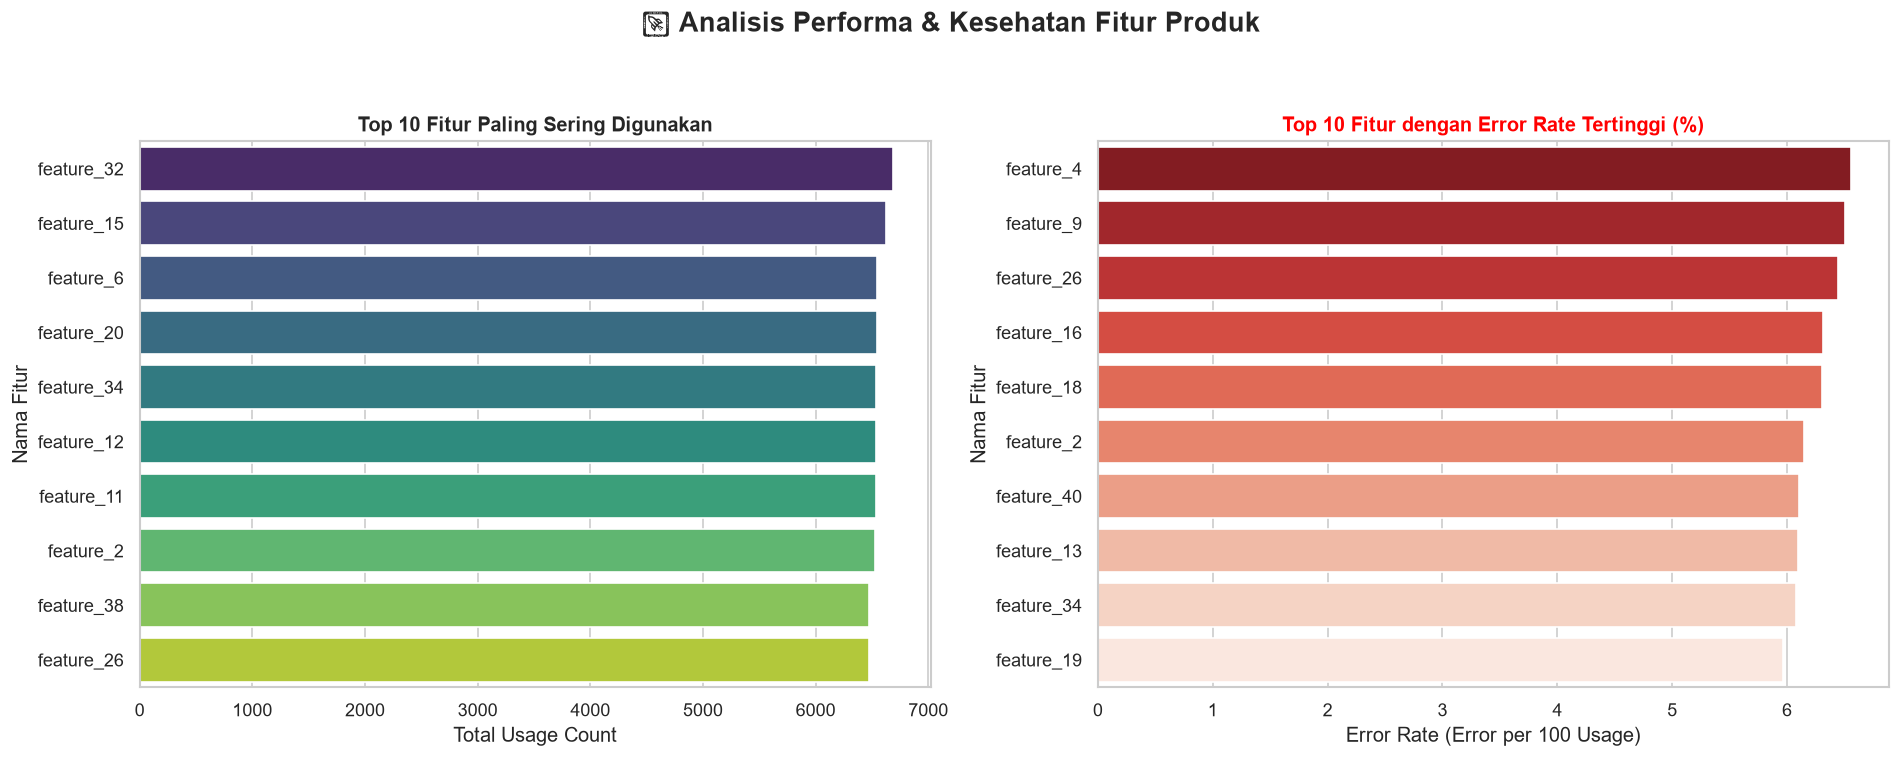

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data Feature Usage
df_features = pd.read_csv('ravenstack_feature_usage.csv')


print(f"Total Subscription  : {df_features['subscription_id'].nunique():,}")
print(f"Rentang Waktu       : {df_features['usage_date'].min()} s/d {df_features['usage_date'].max()}")

# 2. Agregasi Berdasarkan Nama Fitur
print("="*60)
print("2. PERFORMA & KESEHATAN FITUR (TOP 10)")
print("="*60)
feature_stats = df_features.groupby('feature_name').agg(
    total_usage=('usage_count', 'sum'),
    total_duration_hrs=('usage_duration_secs', lambda x: x.sum() / 3600), # Ubah detik ke jam
    total_errors=('error_count', 'sum'),
    is_beta=('is_beta_feature', 'first') # Ambil flag beta (True/False)
).reset_index()

# Menghitung Error Rate (Error per 100 usage)
feature_stats['error_rate_pct'] = (feature_stats['total_errors'] / feature_stats['total_usage']) * 100

# Urutkan berdasarkan fitur paling sering dipakai
top_10_features = feature_stats.sort_values('total_usage', ascending=False).head(10)
print(top_10_features.round(2).to_string(index=False))


# 3. Visualisasi Grafik: 
# A) Top 10 Fitur Paling Banyak Dipakai
# B) Top 10 Fitur Paling Banyak Error
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)
fig.suptitle('🚀 Analisis Performa & Kesehatan Fitur Produk', fontsize=16, fontweight='bold', y=1.05)

# Grafik A: Top 10 Fitur Favorit (Total Usage)
sns.barplot(data=top_10_features, x='total_usage', y='feature_name', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Fitur Paling Sering Digunakan', fontweight='bold')
axes[0].set_xlabel('Total Usage Count')
axes[0].set_ylabel('Nama Fitur')

# Grafik B: Top 10 Fitur dengan Error Rate Tertinggi
top_error_features = feature_stats.sort_values('error_rate_pct', ascending=False).head(10)
sns.barplot(data=top_error_features, x='error_rate_pct', y='feature_name', ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Fitur dengan Error Rate Tertinggi (%)', fontweight='bold', color='red')
axes[1].set_xlabel('Error Rate (Error per 100 Usage)')
axes[1].set_ylabel('Nama Fitur')

plt.tight_layout()
plt.show()


Terdapat irisan (overlap) yang sangat berisiko antara fitur yang paling banyak digunakan dengan fitur yang paling sering mengalami kegagalan (error). Feature_26, Feature_34, dan Feature_2 masuk ke dalam daftar "Top 10 Paling Banyak Digunakan" sekaligus menempati posisi puncak di grafik "Top 10 Error Rate Tertinggi". Gangguan berulang pada fitur-fitur inti inilah yang menjadi pemicu utama tingginya eskalasi tiket keluhan (Support) dan keputusan pelanggan untuk churn.

Khusus untuk Feature_2, tabel data menunjukkan bahwa fitur ini masih berstatus uji coba (is_beta = True). Namun ironisnya, fitur ini menduduki peringkat ke-8 sebagai fitur yang paling banyak diakses oleh pelanggan, dengan tingkat error menembus 6.15%. Membiarkan fitur Beta yang tidak stabil digunakan secara masif oleh pelanggan tingkat Enterprise dan DevTools adalah sebuah kelalaian fatal dalam manajemen produk.

Sehingga ada baiknya tim developer memfokuskan untuk membenahi fitur 26, fitur 2, dan fitur 34

1. FEATURE STICKINESS (Berapa fitur unik per pelanggan?)
Statistik Distribusi Penggunaan Fitur Unik:
count    4967.000000
mean        4.731427
std         1.983913
min         1.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        13.000000
Name: unique_features, dtype: float64

2. RISIKO PRODUK: FITUR BETA vs STABIL
 is_beta_feature  total_usage  total_errors  avg_duration_secs  error_rate_pct
           False       224939         12691            3041.38            5.64
            True        25586          1416            3049.43            5.53


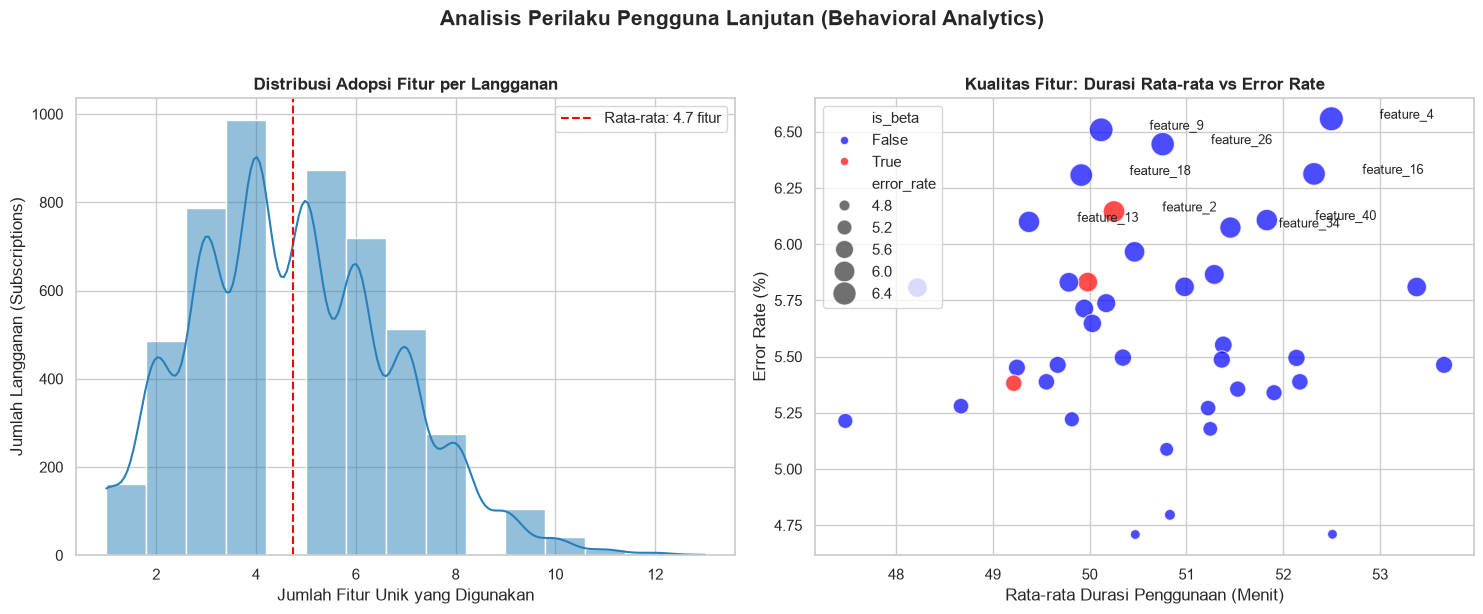

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_features = pd.read_csv('ravenstack_feature_usage.csv')

print("="*60)
print("1. FEATURE STICKINESS (Berapa fitur unik per pelanggan?)")
print("="*60)
# Menghitung berapa banyak fitur unik yang dipakai oleh setiap subscription
subs_breadth = df_features.groupby('subscription_id').agg(
    unique_features=('feature_name', 'nunique')
).reset_index()

print("Statistik Distribusi Penggunaan Fitur Unik:")
print(subs_breadth['unique_features'].describe())

print("\n" + "="*60)
print("2. RISIKO PRODUK: FITUR BETA vs STABIL")
print("="*60)
beta_stats = df_features.groupby('is_beta_feature').agg(
    total_usage=('usage_count', 'sum'),
    total_errors=('error_count', 'sum'),
    avg_duration_secs=('usage_duration_secs', 'mean')
).reset_index()
beta_stats['error_rate_pct'] = (beta_stats['total_errors'] / beta_stats['total_usage']) * 100
print(beta_stats.round(2).to_string(index=False))

# ==========================================
# 3. VISUALISASI: ENGAGEMENT QUALITY & STICKINESS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=100)
fig.suptitle('Analisis Perilaku Pengguna Lanjutan (Behavioral Analytics)', fontsize=15, fontweight='bold', y=1.02)

# Grafik A: Distribusi Stickiness
sns.histplot(data=subs_breadth, x='unique_features', bins=15, kde=True, ax=axes[0], color='#2980b9')
axes[0].set_title('Distribusi Adopsi Fitur per Langganan', fontweight='bold')
axes[0].set_xlabel('Jumlah Fitur Unik yang Digunakan')
axes[0].set_ylabel('Jumlah Langganan (Subscriptions)')
# Garis rata-rata
mean_feat = subs_breadth['unique_features'].mean()
axes[0].axvline(mean_feat, color='red', linestyle='--', label=f'Rata-rata: {mean_feat:.1f} fitur')
axes[0].legend()

# Grafik B: Scatter Plot Kualitas Fitur (Durasi vs Error)
# Kita ingin melihat apakah fitur yang durasinya lama juga banyak errornya
feat_quality = df_features.groupby('feature_name').agg(
    avg_duration_mins=('usage_duration_secs', lambda x: x.mean() / 60),
    error_rate=('error_count', lambda x: x.sum() / df_features.loc[x.index, 'usage_count'].sum() * 100),
    is_beta=('is_beta_feature', 'first')
).reset_index()

sns.scatterplot(data=feat_quality, x='avg_duration_mins', y='error_rate', 
                hue='is_beta', size='error_rate', sizes=(50, 300), 
                palette={True: 'red', False: 'blue'}, alpha=0.7, ax=axes[1])

axes[1].set_title('Kualitas Fitur: Durasi Rata-rata vs Error Rate', fontweight='bold')
axes[1].set_xlabel('Rata-rata Durasi Penggunaan (Menit)')
axes[1].set_ylabel('Error Rate (%)')

# Anotasi fitur dengan error rate tertinggi di atas 6%
for i in range(len(feat_quality)):
    if feat_quality['error_rate'][i] > 6.0:
        axes[1].text(feat_quality['avg_duration_mins'][i] + 0.5, 
                     feat_quality['error_rate'][i], 
                     feat_quality['feature_name'][i], fontsize=9)

plt.tight_layout()
plt.show()


- grafik kiri menunjukkan rata-rata tiap akun  menggunakan 4,7 fitur, padahal perusahaan menyediakan puluan fitur. Sehingga akun yang sudah berlangganan enterprise atau mahal akan sia- sia jika tidak memanfaatkan fitur-fitur yang ada.
- fitur yang sudah stabil memiliki error rate lebih tinggi daripada fitur yang beta, seperti fitur 4,26 dan 9
developer harus lebih memperhatikan fitur lama

# support tickets

1. KINERJA TIM SUPPORT (OVERVIEW UMUM)
Total Tiket Support     : 2,000
Rata-rata Waktu Respon  : 88.5 Menit
Rata-rata Waktu Solusi  : 35.9 Jam
Rata-rata Skor Kepuasan : 3.98 / 5.0
Tiket Tanpa Rating CSAT : 825 (41.2% dari total tiket)

2. KINERJA BERDASARKAN PRIORITAS TIKET
priority  total_tickets  avg_response_mins  avg_resolution_hrs  escalation_rate_pct
     low            485              91.15               36.35                 4.74
  medium            491              85.86               35.59                 5.09
    high            510              91.44               36.96                 4.71
  urgent            514              85.53               34.57                 4.47

3. KORELASI SUPPORT TERHADAP CHURN PELANGGAN
Perbandingan Pengalaman Support (Tetap Aktif vs Churned):
 churn_flag  avg_tickets_created  avg_resolution_hrs  avg_csat
      False                 4.02               36.45      3.95
       True                 3.93               35.49      4.00


C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\3379846589.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_merge, x='churn_flag', y='avg_resolution_hrs', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\3379846589.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Tetap Aktif (False)', 'Churn (True)'])
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\3379846589.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_merge, x='churn_flag', y='avg_csat_score', ax=axes[1

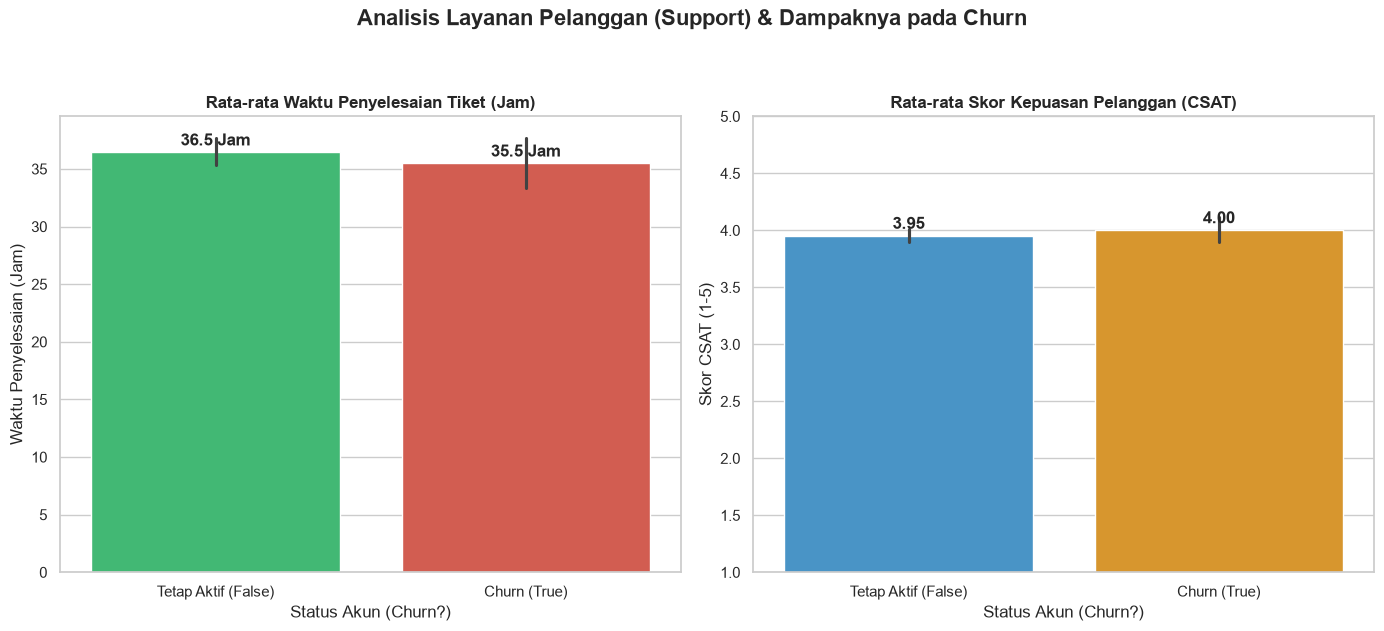

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_tickets = pd.read_csv('ravenstack_support_tickets.csv')
df_acc = pd.read_csv('ravenstack_accounts.csv')

print("="*60)
print("1. KINERJA TIM SUPPORT (OVERVIEW UMUM)")
print("="*60)
print(f"Total Tiket Support     : {len(df_tickets):,}")
print(f"Rata-rata Waktu Respon  : {df_tickets['first_response_time_minutes'].mean():.1f} Menit")
print(f"Rata-rata Waktu Solusi  : {df_tickets['resolution_time_hours'].mean():.1f} Jam")
print(f"Rata-rata Skor Kepuasan : {df_tickets['satisfaction_score'].mean():.2f} / 5.0")
null_csat = df_tickets['satisfaction_score'].isnull().sum()
print(f"Tiket Tanpa Rating CSAT : {null_csat:,} ({null_csat/len(df_tickets)*100:.1f}% dari total tiket)\n")

print("="*60)
print("2. KINERJA BERDASARKAN PRIORITAS TIKET")
print("="*60)
priority_stats = df_tickets.groupby('priority').agg(
    total_tickets=('ticket_id', 'count'),
    avg_response_mins=('first_response_time_minutes', 'mean'),
    avg_resolution_hrs=('resolution_time_hours', 'mean'),
    escalation_rate_pct=('escalation_flag', lambda x: np.mean(x)*100)
).reset_index()

# Urutkan berdasarkan level prioritas
priority_stats['priority'] = pd.Categorical(priority_stats['priority'], categories=['low', 'medium', 'high', 'urgent'], ordered=True)
print(priority_stats.sort_values('priority').round(2).to_string(index=False))


# =======================================================
# 3. PENGGABUNGAN (JOIN) UNTUK MELIHAT DAMPAK KE CHURN
# =======================================================
print("\n" + "="*60)
print("3. KORELASI SUPPORT TERHADAP CHURN PELANGGAN")
print("="*60)

# Merangkum histori tiket per Akun Pelanggan
acc_support = df_tickets.groupby('account_id').agg(
    total_tickets_submitted=('ticket_id', 'count'),
    avg_resolution_hrs=('resolution_time_hours', 'mean'),
    avg_csat_score=('satisfaction_score', 'mean')
).reset_index()

# Gabungkan dengan tabel accounts
df_merge = pd.merge(df_acc, acc_support, on='account_id', how='left')

# Isi akun yang tidak pernah kirim tiket dengan 0
df_merge['total_tickets_submitted'] = df_merge['total_tickets_submitted'].fillna(0)

# Hitung rata-rata metrik support berdasarkan status Churn
churn_impact = df_merge.groupby('churn_flag').agg(
    avg_tickets_created=('total_tickets_submitted', 'mean'),
    avg_resolution_hrs=('avg_resolution_hrs', 'mean'),
    avg_csat=('avg_csat_score', 'mean')
).reset_index()

print("Perbandingan Pengalaman Support (Tetap Aktif vs Churned):")
print(churn_impact.round(2).to_string(index=False))


# =======================================================
# 4. VISUALISASI PEMBUKTIAN CHURN
# =======================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
fig.suptitle('Analisis Layanan Pelanggan (Support) & Dampaknya pada Churn', fontsize=16, fontweight='bold', y=1.05)

# Grafik A: Waktu Penyelesaian
sns.barplot(data=df_merge, x='churn_flag', y='avg_resolution_hrs', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Rata-rata Waktu Penyelesaian Tiket (Jam)', fontweight='bold')
axes[0].set_xlabel('Status Akun (Churn?)')
axes[0].set_ylabel('Waktu Penyelesaian (Jam)')
axes[0].set_xticklabels(['Tetap Aktif (False)', 'Churn (True)'])
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f} Jam", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# Grafik B: Skor Kepuasan (CSAT)
sns.barplot(data=df_merge, x='churn_flag', y='avg_csat_score', ax=axes[1], palette=['#3498db', '#f39c12'])
axes[1].set_title('Rata-rata Skor Kepuasan Pelanggan (CSAT)', fontweight='bold')
axes[1].set_xlabel('Status Akun (Churn?)')
axes[1].set_ylabel('Skor CSAT (1-5)')
axes[1].set_xticklabels(['Tetap Aktif (False)', 'Churn (True)'])
axes[1].set_ylim(1, 5) # CSAT biasanya dari 1 sampai 5
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()


Data menunjukkan tidak ada korelasi antara pengalaman di layanan Support dengan keputusan churn. Pelanggan yang kabur maupun yang bertahan memiliki jumlah keluhan dan waktu tunggu penyelesaian yang nyaris identik. Secara mengejutkan, pelanggan yang churn justru memberikan skor kepuasan (CSAT) yang sedikit lebih tinggi (4.00 vs 3.95). Begitu juga dengan rata-rata waktu penyelesaian, bedanya antara yang churn dan masih aktif tidak terlalu jauh

1. OTOPSI CHURN (ALASAN UTAMA PELANGGAN PERGI)
reason_code  total_churn  avg_refund_usd  persentase_pct
   features          114           16.72           19.00
     budget          104           12.00           17.33
    support          104           11.73           17.33
    unknown           95           18.34           15.83
 competitor           92           13.08           15.33
    pricing           91           14.65           15.17

2. APAKAH PELANGGAN YANG CHURN PERNAH KEMBALI? (REACTIVATION)
Tidak Kembali / Benar-benar Pergi : 89.8%
Pernah Kembali Lagi (Reactivated) : 10.2%


C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\1072113532.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=reason_stats, y='reason_code', x='persentase_pct', palette='rocket')


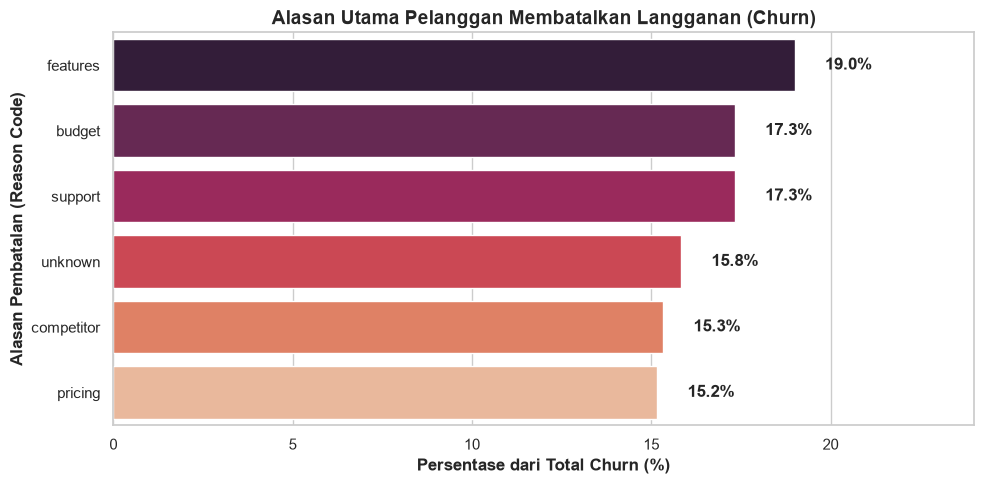

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data Otopsi (Churn Events)
df_churn = pd.read_csv('ravenstack_churn_events.csv')

print("="*60)
print("1. OTOPSI CHURN (ALASAN UTAMA PELANGGAN PERGI)")
print("="*60)
reason_stats = df_churn.groupby('reason_code').agg(
    total_churn=('churn_event_id', 'count'),
    avg_refund_usd=('refund_amount_usd', 'mean')
).reset_index().sort_values('total_churn', ascending=False)

reason_stats['persentase_pct'] = (reason_stats['total_churn'] / len(df_churn)) * 100
print(reason_stats.round(2).to_string(index=False))

print("\n" + "="*60)
print("2. APAKAH PELANGGAN YANG CHURN PERNAH KEMBALI? (REACTIVATION)")
print("="*60)
reactivation = df_churn['is_reactivation'].value_counts(normalize=True) * 100
print(f"Tidak Kembali / Benar-benar Pergi : {reactivation.get(False, 0):.1f}%")
print(f"Pernah Kembali Lagi (Reactivated) : {reactivation.get(True, 0):.1f}%")


# Visualisasi Alasan Churn
plt.figure(figsize=(10, 5), dpi=100)
ax = sns.barplot(data=reason_stats, y='reason_code', x='persentase_pct', palette='rocket')
plt.title('Alasan Utama Pelanggan Membatalkan Langganan (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Persentase dari Total Churn (%)', fontweight='bold')
plt.ylabel('Alasan Pembatalan (Reason Code)', fontweight='bold')

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%", (p.get_width() + 1.5, p.get_y() + p.get_height() / 2.),
                 ha='center', va='center', fontweight='bold')

plt.xlim(0, reason_stats['persentase_pct'].max() + 5)
plt.tight_layout()
plt.show()


- Survei pembatalan (exit survey) mengonfirmasi bahwa kendala fungsionalitas produk (Features) adalah alasan utama nomor satu (19.0%) pelanggan meninggalkan perusahaan. Data ini memvalidasi seluruh hipotesis teknis sebelumnya: kualitas software yang buruk dan tingginya tingkat error pada fitur inti adalah pembunuh utama kelangsungan bisnis RavenStack.

- Alasan Budget kemungkinan besar hanya penolakan halus (polite excuse) karena keluhan utama soal Harga (Pricing) justru berada di urutan terbawah. Begitu pula alasan Support; pelanggan kabur bukan karena kinerja agen CS yang buruk (terbukti skor CSAT tetap tinggi), melainkan karena mereka kelelahan harus terus-menerus melapor ke CS akibat aplikasi yang sering error.

- Sebanyak 89.8% pelanggan yang membatalkan langganan tidak pernah kembali lagi. Kekecewaan akibat kualitas aplikasi yang buruk telah menghancurkan kepercayaan secara permanen. Hal ini membuat peluang akuisisi ulang (Reactivation) hampir mustahil, sehingga fokus utama perusahaan harus digeser 100% pada pencegahan churn (Retensi).

# subscriptions

Total MRR Saat Ini     : $10,159,608.00
Rata-rata MRR/Subs     : $2,250.69
Total Missing Values   : 4514 (Biasanya pada end_date jika belum churn)

2. UPGRADE VS DOWNGRADE BEHAVIOR
Riwayat Upgrade Plan  : 529 kali
Riwayat Downgrade Plan: 218 kali

3. CHURN RATE: MONTHLY VS ANNUAL BILLING
billing_frequency  total_subs  churned_subs  churn_rate_pct
           annual        2461           247       10.036570
          monthly        2539           239        9.413155

4. DAMPAK AUTO-RENEW TERHADAP CHURN
 auto_renew_flag  total_subs  churned_subs  churn_rate_pct
           False         995            96        9.648241
            True        4005           390        9.737828


C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\3944594497.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mrr_by_tier, x='plan_tier', y='mrr_amount', ax=axes[0], palette='Greens')
C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\3944594497.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=billing_stats, x='billing_frequency', y='churn_rate_pct', ax=axes[1], palette='Oranges')


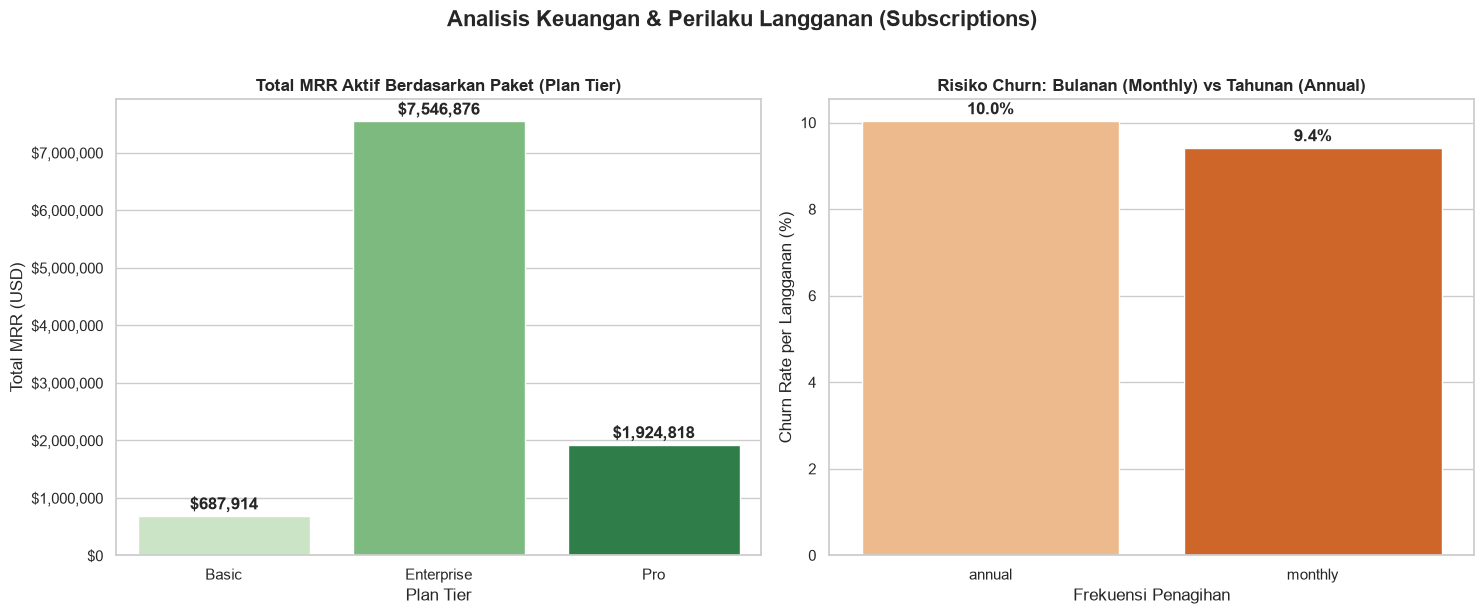

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Data Subscriptions
df_subs = pd.read_csv('ravenstack_subscriptions.csv')

print(f"Total MRR Saat Ini     : ${df_subs[df_subs['churn_flag'] == False]['mrr_amount'].sum():,.2f}")
print(f"Rata-rata MRR/Subs     : ${df_subs[df_subs['churn_flag'] == False]['mrr_amount'].mean():,.2f}")
print(f"Total Missing Values   : {df_subs.isnull().sum().sum()} (Biasanya pada end_date jika belum churn)\n")

print("="*60)
print("2. UPGRADE VS DOWNGRADE BEHAVIOR")
print("="*60)
upgrades = df_subs['upgrade_flag'].sum()
downgrades = df_subs['downgrade_flag'].sum()
print(f"Riwayat Upgrade Plan  : {upgrades} kali")
print(f"Riwayat Downgrade Plan: {downgrades} kali")

# 3. Analisis Frekuensi Penagihan (Bulanan vs Tahunan)
print("\n" + "="*60)
print("3. CHURN RATE: MONTHLY VS ANNUAL BILLING")
print("="*60)
billing_stats = df_subs.groupby('billing_frequency').agg(
    total_subs=('subscription_id', 'count'),
    churned_subs=('churn_flag', 'sum')
).reset_index()
billing_stats['churn_rate_pct'] = (billing_stats['churned_subs'] / billing_stats['total_subs']) * 100
print(billing_stats.to_string(index=False))

# 4. Analisis Auto-Renew
print("\n" + "="*60)
print("4. DAMPAK AUTO-RENEW TERHADAP CHURN")
print("="*60)
autorenew_stats = df_subs.groupby('auto_renew_flag').agg(
    total_subs=('subscription_id', 'count'),
    churned_subs=('churn_flag', 'sum')
).reset_index()
autorenew_stats['churn_rate_pct'] = (autorenew_stats['churned_subs'] / autorenew_stats['total_subs']) * 100
print(autorenew_stats.to_string(index=False))


# 5. Visualisasi 
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=100)
fig.suptitle('Analisis Keuangan & Perilaku Langganan (Subscriptions)', fontsize=16, fontweight='bold', y=1.02)

# Grafik A: Kontribusi MRR Berdasarkan Plan Tier (Hanya yang Aktif/Belum Churn)
active_subs = df_subs[df_subs['churn_flag'] == False]
mrr_by_tier = active_subs.groupby('plan_tier')['mrr_amount'].sum().reset_index()
sns.barplot(data=mrr_by_tier, x='plan_tier', y='mrr_amount', ax=axes[0], palette='Greens')
axes[0].set_title('Total MRR Aktif Berdasarkan Paket (Plan Tier)', fontweight='bold')
axes[0].set_ylabel('Total MRR (USD)')
axes[0].set_xlabel('Plan Tier')
# Format Y-axis ke bentuk Dollar
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))
for p in axes[0].patches:
    axes[0].annotate(f"${int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# Grafik B: Dampak Bulanan vs Tahunan Terhadap Churn
sns.barplot(data=billing_stats, x='billing_frequency', y='churn_rate_pct', ax=axes[1], palette='Oranges')
axes[1].set_title('Risiko Churn: Bulanan (Monthly) vs Tahunan (Annual)', fontweight='bold')
axes[1].set_ylabel('Churn Rate per Langganan (%)')
axes[1].set_xlabel('Frekuensi Penagihan')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()


- sebagian besar pendapatan perusahaan berasal dari pelanggan yang membeli paket termahal (Enterprise). Artinya, perusahaan ini sangat bergantung pada sedikit pelanggan kaya. Jika satu pelanggan Enterprise ini marah dan kabur karena aplikasinya error, kerugian uangnya jauh lebih menyakitkan bagi perusahaan daripada kehilangan puluhan pelanggan paket murah (Basic).

- Biasanya, pelanggan yang membayar untuk 1 tahun penuh (Annual) adalah pelanggan yang paling awet. Tapi anehnya di grafik kanan, pelanggan tahunan kita malah lebih banyak yang kabur daripada pelanggan bulanan! Ini artinya mereka sangat kecewa dan merasa "terjebak" memakai aplikasi yang sering error selama setahun penuh. Begitu kontrak tahunannya habis, mereka langsung pergi dan kapok.

1. FINANCIAL IMPACT: MRR CHURN
Total MRR Tetap Aktif  : $10,159,608.00
Total MRR Menguap/Churn: $1,179,139.00  <-- Uang yang hilang tiap bulan!

2. INVESTIGASI ANOMALI: ANNUAL vs MONTHLY CHURN
Tabel Churn Rate (%) berdasarkan Status Trial & Frekuensi Bayar:
billing_frequency  annual  monthly
is_trial                          
False               10.35     8.99
True                 8.29    11.63

Insight: Coba perhatikan apakah pelanggan Trial yang terjebak Annual yang merusak angka churn!

3. DOWNGRADE SEBAGAI PREDIKTOR CHURN?
    plan_history  total_subs  churn_rate_pct
Pernah Downgrade         195       10.769231
   Tidak Berubah        4276        9.798877
  Pernah Upgrade         529        8.695652


C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\176485994.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=change_churn, x='plan_history', y='churn_rate_pct', palette='coolwarm_r')


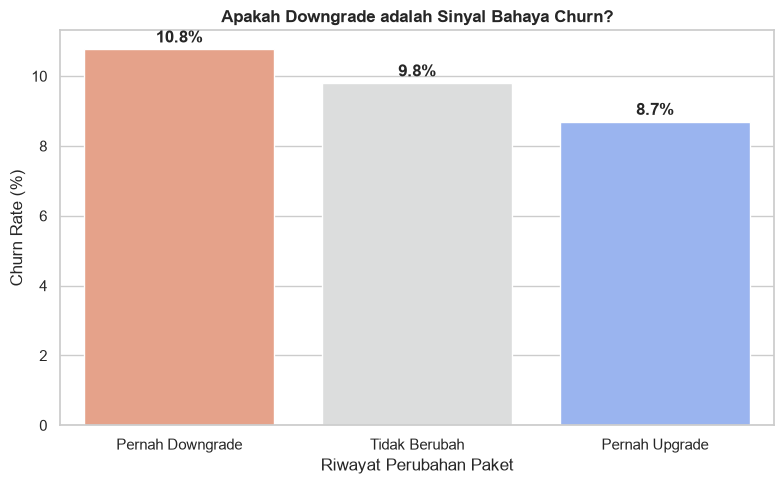

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_subs = pd.read_csv('ravenstack_subscriptions.csv')

print("="*60)
print("1. FINANCIAL IMPACT: MRR CHURN")
print("="*60)
# MRR yang hilang dianggap dari nilai MRR terakhir sebelum churn (jika MRR 0 karena trial, arr/mrr asal bisa diestimasi, tapi kita hitung dari kolom mrr_amount)
mrr_lost = df_subs[df_subs['churn_flag'] == True]['mrr_amount'].sum()
mrr_active = df_subs[df_subs['churn_flag'] == False]['mrr_amount'].sum()
print(f"Total MRR Tetap Aktif  : ${mrr_active:,.2f}")
print(f"Total MRR Menguap/Churn: ${mrr_lost:,.2f}  <-- Uang yang hilang tiap bulan!")

print("\n" + "="*60)
print("2. INVESTIGASI ANOMALI: ANNUAL vs MONTHLY CHURN")
print("="*60)
# Memisahkan churn berdasarkan Trial vs Non-Trial dan Billing Frequency
pivot_anomaly = pd.pivot_table(
    df_subs, 
    values='churn_flag', 
    index='is_trial', 
    columns='billing_frequency', 
    aggfunc=lambda x: np.mean(x)*100
)
print("Tabel Churn Rate (%) berdasarkan Status Trial & Frekuensi Bayar:")
print(pivot_anomaly.round(2))
print("\nInsight: Coba perhatikan apakah pelanggan Trial yang terjebak Annual yang merusak angka churn!")

print("\n" + "="*60)
print("3. DOWNGRADE SEBAGAI PREDIKTOR CHURN?")
print("="*60)
# Mengelompokkan status perubahan plan
def categorize_change(row):
    if row['upgrade_flag']: return 'Pernah Upgrade'
    if row['downgrade_flag']: return 'Pernah Downgrade'
    return 'Tidak Berubah'

df_subs['plan_history'] = df_subs.apply(categorize_change, axis=1)

change_churn = df_subs.groupby('plan_history').agg(
    total_subs=('subscription_id', 'count'),
    churn_rate_pct=('churn_flag', lambda x: np.mean(x)*100)
).reset_index().sort_values('churn_rate_pct', ascending=False)
print(change_churn.to_string(index=False))

# --- Visualisasi Sederhana ---
plt.figure(figsize=(8, 5), dpi=100)
ax = sns.barplot(data=change_churn, x='plan_history', y='churn_rate_pct', palette='coolwarm_r')
plt.title('Apakah Downgrade adalah Sinyal Bahaya Churn?', fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Riwayat Perubahan Paket')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()



3. DOWNGRADE SEBAGAI PREDIKTOR CHURN?
                plan_history  total_subs  churn_rate_pct
Pernah Keduanya (Fluktuatif)          23       17.391304
            Pernah Downgrade         195       10.769231
               Tidak Berubah        4276        9.798877
              Pernah Upgrade         506        8.300395


C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\1782892613.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=change_churn, x='plan_history', y='churn_rate_pct', palette='coolwarm_r')


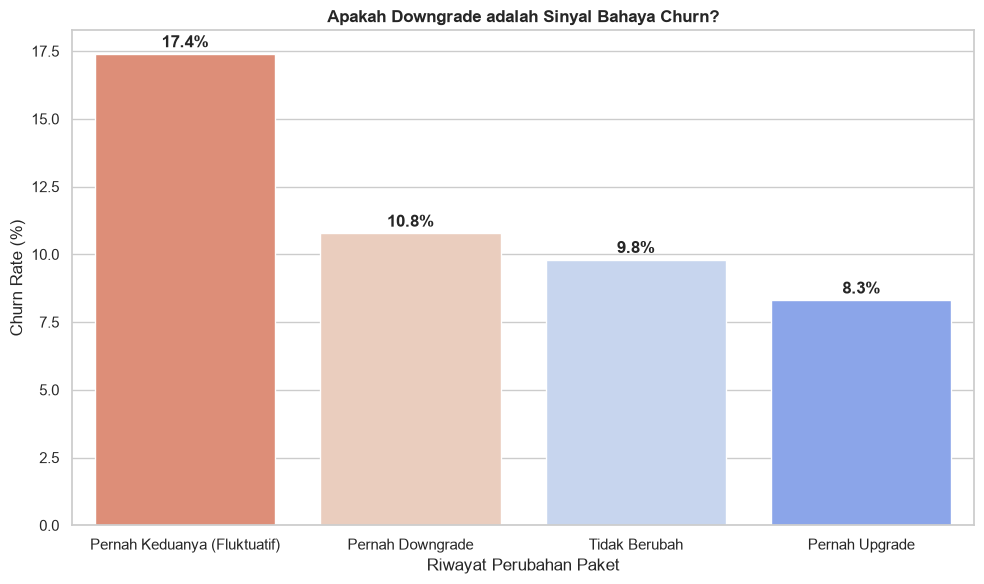

In [95]:
print("\n" + "="*60)
print("3. DOWNGRADE SEBAGAI PREDIKTOR CHURN?")
print("="*60)

# Mengelompokkan status perubahan plan dengan logika yang disempurnakan
def categorize_change(row):
    # Cek dulu apakah dia pernah melakukan KEDUANYA (Upgrade sekaligus Downgrade)
    if row['upgrade_flag'] and row['downgrade_flag']: 
        return 'Pernah Keduanya (Fluktuatif)'
    if row['upgrade_flag']: 
        return 'Pernah Upgrade'
    if row['downgrade_flag']: 
        return 'Pernah Downgrade'
    return 'Tidak Berubah'

df_subs['plan_history'] = df_subs.apply(categorize_change, axis=1)

change_churn = df_subs.groupby('plan_history').agg(
    total_subs=('subscription_id', 'count'),
    churn_rate_pct=('churn_flag', lambda x: np.mean(x)*100)
).reset_index().sort_values('churn_rate_pct', ascending=False)
print(change_churn.to_string(index=False))

# --- Visualisasi Sederhana ---
plt.figure(figsize=(10, 6), dpi=100)
ax = sns.barplot(data=change_churn, x='plan_history', y='churn_rate_pct', palette='coolwarm_r')
plt.title('Apakah Downgrade adalah Sinyal Bahaya Churn?', fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Riwayat Perubahan Paket')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()


- Kerugian Finansial Tiap Bulan Perusahaan kehilangan pendapatan sebesar $1,17 Juta (sekitar Rp 18 Miliar) setiap bulannya dari pelanggan yang berhenti berlangganan. Kerugian rutin ini akan sangat berbahaya bagi kondisi keuangan perusahaan jika masalah pada aplikasi tidak segera diperbaiki.

- Pelanggan Tahunan Lebih Sering Berhenti Biasanya pelanggan tahunan adalah yang paling awet, tapi data kita menunjukkan sebaliknya. Pelanggan asli (bukan Trial) yang membayar lunas satu tahun penuh justru paling banyak membatalkan langganan (10.35%). Hal ini mengindikasikan mereka sangat kecewa setelah terlanjur berkomitmen panjang, sehingga langsung berhenti begitu masa kontraknya habis.

- "Perubahan Paket" sebagai Sinyal Bahaya Grafik terbaru menunjukkan cara jitu untuk memprediksi pelanggan yang akan kabur berdasarkan riwayat paketnya:

Sangat Bahaya (Tingkat Kabur 17.4%): Pelanggan yang "labil" atau berfluktuasi (pernah naik paket, lalu turun paket lagi). Mereka sangat kebingungan dengan nilai produk yang didapat.
Bahaya (Tingkat Kabur 10.8%): Pelanggan yang murni hanya meminta turun paket (Downgrade). Saran Tindakan: Jika tim Sales melihat ada pelanggan dengan dua ciri di atas, segera telepon dan tanyakan keluhannya, karena itu adalah tanda pasti mereka akan segera kabur selamanya.

Mengagregasi data feature usage...


C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20556\641255493.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_by_error, x='error_category', y='churn_rate', palette='flare')


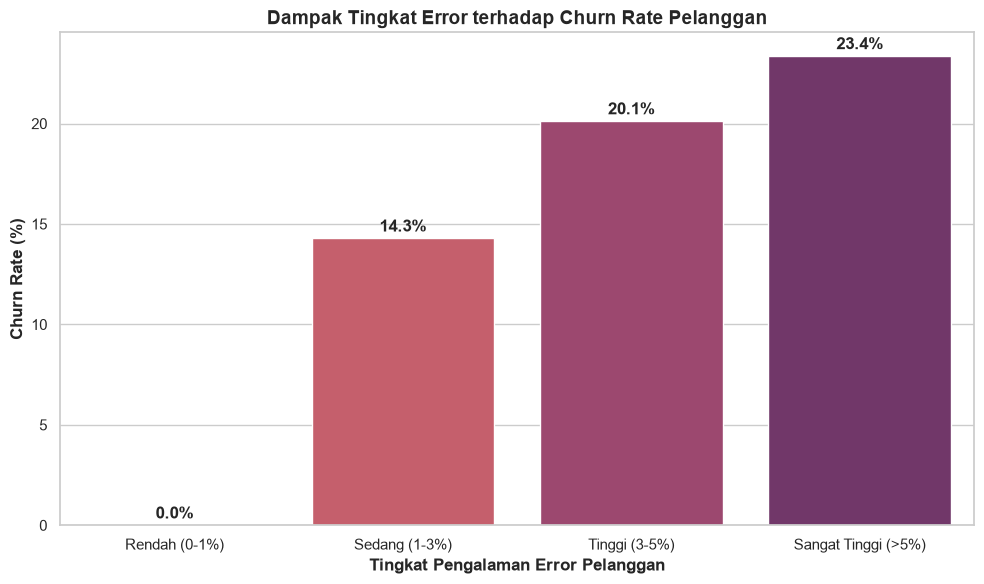


--- RINGKASAN DATA FINAL ---
        error_category  total_accounts  churn_rate
0        Rendah (0-1%)               1    0.000000
1        Sedang (1-3%)              14   14.285714
2        Tinggi (3-5%)             164   20.121951
3  Sangat Tinggi (>5%)             321   23.364486


In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load semua tabel yang dibutuhkan
df_acc = pd.read_csv('ravenstack_accounts.csv')
df_subs = pd.read_csv('ravenstack_subscriptions.csv')
df_feat = pd.read_csv('ravenstack_feature_usage.csv')

# 2. Agregasi Feature Usage per Subscription
print("Mengagregasi data feature usage...")
feat_agg = df_feat.groupby('subscription_id').agg(
    total_usage=('usage_count', 'sum'),
    total_errors=('error_count', 'sum')
).reset_index()

# Hitung Error Rate per Subscription
feat_agg['error_rate_pct'] = (feat_agg['total_errors'] / feat_agg['total_usage']) * 100

# 3. Penggabungan Data (Merge)
# A. Gabungkan feature_agg ke subscriptions
df_merge1 = pd.merge(df_subs, feat_agg, on='subscription_id', how='left')

# Karena satu akun bisa punya banyak subscription (misal renewal), 
# kita agregasi lagi error rate di level Account
acc_feat_agg = df_merge1.groupby('account_id').agg(
    avg_error_rate=('error_rate_pct', 'mean')
).reset_index()

# B. Gabungkan hasilnya ke tabel accounts
df_final = pd.merge(df_acc, acc_feat_agg, on='account_id', how='left')
df_final['avg_error_rate'] = df_final['avg_error_rate'].fillna(0) # Isi 0 jika tidak ada data usage

# 4. Analisis Korelasi: Error Rate vs Churn
# Mari kita kelompokkan pelanggan berdasarkan tingkat error yang mereka alami
bins = [-1, 1, 3, 5, 100]
labels = ['Rendah (0-1%)', 'Sedang (1-3%)', 'Tinggi (3-5%)', 'Sangat Tinggi (>5%)']
df_final['error_category'] = pd.cut(df_final['avg_error_rate'], bins=bins, labels=labels)

churn_by_error = df_final.groupby('error_category', observed=False).agg(
    total_accounts=('account_id', 'count'),
    churned=('churn_flag', 'sum')
).reset_index()
churn_by_error['churn_rate'] = (churn_by_error['churned'] / churn_by_error['total_accounts']) * 100

# 5. Visualisasi Hasil Pembuktian
plt.figure(figsize=(10, 6), dpi=100)
ax = sns.barplot(data=churn_by_error, x='error_category', y='churn_rate', palette='flare')
plt.title('Dampak Tingkat Error terhadap Churn Rate Pelanggan', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Pengalaman Error Pelanggan', fontweight='bold')
plt.ylabel('Churn Rate (%)', fontweight='bold')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- RINGKASAN DATA FINAL ---")
print(churn_by_error[['error_category', 'total_accounts', 'churn_rate']])


-  Aplikasi Lancar = Pelanggan Setia (Bukti di Balok Pertama) Pelanggan yang aplikasinya berjalan mulus dan sangat jarang error (di bawah 1%) ternyata tidak ada yang kabur sama sekali (Tingkat Churn 0%)!
- Pola Tangga yang Berbahaya Grafik ini membentuk pola tangga yang sempurna. Semakin sering pelanggan menabrak error saat memakai aplikasi, semakin besar niat mereka untuk kabur. Angkanya melompat drastis dari 0%, ke 14%, lalu 20%, dan puncaknya 23.4%

In [56]:
# 1. subscription pertama tiap akun
subs_sorted = subs.sort_values('start_date')
first_sub = subs_sorted.groupby('account_id').first().reset_index()[['account_id', 'start_date']]
first_sub.columns = ['account_id', 'first_start']

# 2. churn pertama tiap akun
first_churn = churn.groupby('account_id')['churn_date'].min().reset_index()
first_churn.columns = ['account_id', 'churn_date']

# 3. gabung, hitung lifespan dalam bulan
lifespan = first_sub.merge(first_churn, on='account_id')
lifespan['first_start'] = pd.to_datetime(lifespan['first_start'])
lifespan['churn_date'] = pd.to_datetime(lifespan['churn_date'])
lifespan['lifespan_months'] = (
    (lifespan['churn_date'].dt.year - lifespan['first_start'].dt.year) * 12
    + (lifespan['churn_date'].dt.month - lifespan['first_start'].dt.month)
)

# 4. ARPU per akun
arpu = subs.groupby('account_id')['mrr_amount'].mean().reset_index()
arpu.columns = ['account_id', 'avg_mrr']

# 5. gabung semua + industry, hitung LTV per industry
merged = lifespan.merge(arpu, on='account_id').merge(accounts[['account_id', 'industry']], on='account_id')
merged = merged[merged['lifespan_months'] >= 0]

ltv_per_industry = merged.groupby('industry').agg(
    n_churned_accounts=('account_id', 'count'),
    avg_lifespan_months=('lifespan_months', 'mean'),
    arpu_usd=('avg_mrr', 'mean'),
).reset_index()
ltv_per_industry['estimated_ltv_usd'] = ltv_per_industry['avg_lifespan_months'] * ltv_per_industry['arpu_usd']
ltv_per_industry.sort_values('estimated_ltv_usd', ascending=False).round(2)

,industry,n_churned_accounts,avg_lifespan_months,arpu_usd,estimated_ltv_usd
4,HealthTech,61,4.31,2253.35,9715.25
3,FinTech,71,3.69,2382.04,8790.07
1,DevTools,75,4.04,2141.62,8652.15
0,Cybersecurity,62,3.37,2328.87,7850.56
2,EdTech,54,3.09,2372.30,7336.54


1. ARPU (Rata-Rata Uang Masuk Tiap Bulan) Tim Sales sebenarnya sangat hebat. Mereka berhasil merayu pelanggan kaya yang mau membayar rata-rata $2.200 setiap bulannya (Angka bulanan inilah yang disebut ARPU).

2. Umur Pelanggan Sangat Pendek Sayangnya, jerih payah Sales sia-sia. Karena aplikasinya rusak dan banyak bug, pelanggan rata-rata hanya sanggup bertahan selama 3 sampai 4 bulan saja sebelum akhirnya kabur. Untuk bisnis software kantoran, langganan cuma 3 bulan adalah rekor yang sangat memalukan (normalnya bertahun-tahun).

3. LTV (Total Keseluruhan Uang yang Gagal Didapat) LTV adalah total keseluruhan uang yang didapat dari awal pelanggan masuk sampai kabur (ARPU dikali umur). Saat ini, total uang (LTV) per pelanggan mentok di angka $8.800 karena mereka sudah kabur di bulan ke-4. Jika saja aplikasi ini lancar dan pelanggan mau bertahan minimal 1 tahun saja, LTV ini bisa meledak hingga $26.400 per pelanggan

In [57]:
# Total pemakaian per fitur
usage_per_feature = feature.groupby('feature_name').agg(
    total_usage_count=('usage_count', 'sum'),
    total_events=('usage_id', 'count'),
    avg_error_count=('error_count', 'mean'),
).reset_index().sort_values('total_usage_count', ascending=False)

print(usage_per_feature.head(10))

   feature_name  total_usage_count  total_events  avg_error_count
25   feature_32               6686           659         0.541730
6    feature_15               6621           640         0.545312
36    feature_6               6546           655         0.517557
12   feature_20               6541           643         0.479005
27   feature_34               6536           650         0.610769
3    feature_12               6534           659         0.544765
2    feature_11               6533           643         0.547434
11    feature_2               6525           642         0.624611
31   feature_38               6478           643         0.553655
18   feature_26               6470           649         0.642527


Data ini mengonfirmasi secara matematis bahwa fitur-fitur yang menjadi "jantung" aplikasi (paling sering dipakai), justru adalah fitur yang paling sering rusak/macet. Wajar saja pelanggan sangat marah dan langsung membatalkan langganan. Tim pembuat aplikasi (Programmer) harus segera memperbaiki ketiga fitur di atas hari ini juga sebelum mencari pelanggan baru!

# Business Insights

1. Kualitas Produk Menjadi Penyebab Utama Churn

Penyebab terbesar pelanggan berhenti berlangganan adalah masalah fitur (feature issues), yang diperkuat oleh tingginya keluhan terkait fitur kurang lengkap dan perpindahan ke kompetitor. Analisis menunjukkan bahwa peningkatan error aplikasi berkorelasi kuat dengan churn, di mana pelanggan dengan tingkat error tinggi memiliki kemungkinan berhenti jauh lebih besar. Fitur utama yang sering digunakan pelanggan juga menjadi penyumbang error terbesar.

2. Masalah Retensi dan Pengalaman Pelanggan

Retensi pelanggan mengalami penurunan signifikan, terutama pada kohort akhir 2024 yang hanya mampu mempertahankan sekitar 35% pengguna sejak bulan pertama. Selain itu, rata-rata waktu penyelesaian tiket support mencapai 35,86 jam, sehingga lambatnya layanan menjadi faktor yang memperbesar risiko churn. Banyak pelanggan yang tidak memberikan rating kepuasan sebelum pergi, mengindikasikan adanya silent churn.

3. Strategi Penjualan Belum Sejalan dengan Retensi

Jalur Pameran (Event) Berbahaya: Tim Marketing berhasil merayu pelanggan pameran untuk membeli paket premium (76% memilih paket mahal). Sayangnya, mereka memiliki tingkat kabur tertinggi (30.2%). Ini menunjukkan adanya janji berlebihan (overpromise) yang tidak sesuai dengan realita rusaknya aplikasi.
Pelanggan Tahunan Merasa Terjebak: Pelanggan non-trial yang langsung membayar lunas satu tahun justru paling banyak kabur (10.35%) dibanding pelanggan bulanan. Mereka kecewa berat setelah berkomitmen panjang dan langsung pergi begitu masa tahunannya habis.

Umur Pelanggan Super Pendek: Rata-rata pelanggan (bahkan dari industri kesehatan yang paling awet sekalipun) hanya sanggup bertahan 3 hingga 4 bulan sebelum akhirnya menyerah dan pergi.
Kehilangan LTV Raksasa: Tim Sales sangat hebat dalam menjual (Rata-rata uang masuk / ARPU mencapai $2.200 per bulan). Namun karena umur pelanggan hanya 4 bulan, total uang dari satu pelanggan hanya mentok di ~$8.800. Jika aplikasi diperbaiki dan pelanggan bertahan minimal 1 tahun, pendapatan bisa meroket menjadi $26.400 per pelanggan.

4. Sinyal Peringatan Churn
Pelanggan yang meminta turun paket (Downgrade) atau berstatus labil (pernah naik lalu turun paket) memiliki risiko kabur sangat tinggi (mencapai 17.4%). Ini adalah sinyal peringatan bahaya yang paling akurat.

# Rekomendasi

1. Feature Freeze (Pembekuan Fitur Baru) Segera perintahkan departemen IT untuk berhenti membuat fitur baru. Seluruh tim Programmer harus difokuskan 100% untuk membasmi bug, menstabilkan server, dan memperbaiki 3 fitur penyumbang error terbesar hari ini juga.

2. Evaluasi Pemasaran & Janji Sales Hentikan sementara membuang anggaran besar untuk pameran (Event). Fokuskan anggaran untuk mencari pelanggan dari jalur Organik atau Kemitraan (Partner) yang terbukti memiliki loyalitas tinggi (Churn rendah). Larang tim Sales memberikan janji fungsionalitas yang belum stabil kepada calon pelanggan.

3. Bentuk Sistem "Pasukan Penyelamat" Wajibkan tim Customer Success (CS) untuk langsung menelepon pelanggan dalam waktu 1x24 jam apabila mendeteksi adanya pelanggan yang menekan tombol Turun Paket (Downgrade). Cegat mereka sebelum mereka membatalkan langganan selamanya.

4. Perbaiki Prioritas Tiket Keluhan Ubah SOP tim Layanan Pelanggan. Jangan lagi menyelesaikan keluhan semata-mata berdasarkan urutan antrean (FIFO). Keluhan berstatus "Urgent" harus diselesaikan dalam hitungan jam, bukan lagi dibiarkan menunggu hingga 34 jam seperti yang terjadi saat ini.